# Objectif 

L'objectif de ce notebook est d'illustrer les différents estimateurs du vecteur de RTF en terme : 

* De justesse (biais) 
* De fidélité (écart type de l'erreur)
* De temps de calcul 

Les méthodes Cs, CW, CS-EVD testée repose sur l'hypothèse de stationnarité au sens large des signaux considérés afin d'estimer les composantes fréquentielles du vecteur de RTF bin fréquentiel par bin fréquentiel (Bologni et al. 2025, Napolitano 2020). Afin de tester cette hypothèse plusieurs signaux sources sont considérés : 

* Bruit blanc : stationnaire au sens large 
* Bruit rose : légèrement non stationnaire 
* Chirp LFM : fortement non stationnaire 

En particulier, on s'intéresse à la propagation dans un canal de propagation dons les paramètres sont ajustés pour réduire la durée de la réponse impulsionnelle et ainsi réduire la taille des fenêtres utilisées pour le calcul des matrices de covariances et donc pour le calcul du vecteur de RTF. 

L'environnement considéré est un guide d'onde de Pekeris dont les paramètres sont les suivants : 

* Dans la colonne d'eau :
    * $c_0 = 1500 m/s$
    * $\rho_0 = 1000 kg/m^3$
* Dans le sédiment : 
    * $c_1 = 1600 m/s$
    * $\rho_1 = 1500 kg/m^3$
    * $\alpha_1 = 0.2 dB/\lambda$

Références : 
* Bologni, G., Hendriks, R. C., & Heusdens, R. (2025). Wideband Relative Transfer Function (RTF) Estimation Exploiting Frequency Correlations. IEEE Transactions on Audio, Speech and Language Processing, 33, 731–747. https://doi.org/10.1109/TASLPRO.2025.3533371
* Napolitano, A. (2020). A - Nonstationary signal analysis. In A. Napolitano (Ed.), Cyclostationary Processes and Time Series (pp. 471–478). Academic Press. https://doi.org/https://doi.org/10.1016/B978-0-08-102708-0.00028-5


In [29]:
import os
import sys
import time
import numpy as np
import xarray as xr
import scipy.signal as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

# Load usefull functions
from signals.AcousticComponent import AcousticSource
from source.signal_generator import SignalGenerator
from source.rtf_estimator import RTFEstimator

import source.global_constants as g
from publication.publication_figure import PubFigure, LargeFigure, SmallFigure
from misc import mult_along_axis, cast_matrix_to_target_shape
from propa.rtf.rtf_utils import D_hermitian_angle_fast

pfig = PubFigure()
language = "fr" 

In [30]:
name = "pekeris_short_ir_waveguide"

root =r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_estimation"
folder_root = os.path.join(root, name)
tc_root_dir = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\kraken_toolbox\testcases"
)
img_folder_path = os.path.join(folder_root, "img")
data_folder_path = os.path.join(folder_root, "data")

tf_fpath = os.path.join(data_folder_path, "tf_perf.nc")
ir_fpath = os.path.join(data_folder_path, "ir.nc")

In [31]:
sg = SignalGenerator()

# Build testcase informations

In [32]:
hla_rtf_fpath = os.path.join(data_folder_path, f"hla_rtf.nc")

In [33]:
testcase_infos = {}
sig_names = ["pulse", "white_noise", "pink_noise", "chirp_lfm"]
n_tests = len(sig_names)
for i_tc, sig_name in enumerate(sig_names):
    testcase_infos[i_tc] = {
        "name": sig_name,
        "sig_fpath": os.path.join(data_folder_path, f"sig_{sig_name}.nc"),
        "hla_sig_fpath": os.path.join(data_folder_path, f"hla_sig_{sig_name}.nc"),
    }

    print(f"Testcase {i_tc}: ")
    print(testcase_infos[i_tc])

Testcase 0: 
{'name': 'pulse', 'sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\sig_pulse.nc', 'hla_sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\hla_sig_pulse.nc'}
Testcase 1: 
{'name': 'white_noise', 'sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\sig_white_noise.nc', 'hla_sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\hla_sig_white_noise.nc'}
Testcase 2: 
{'name': 'pink_noise', 'sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\sig_pink_noise.nc', 'hla_sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\hla_sig_pink_noi

# Introduce useful functions

In [34]:
def propagate_sig(tf_xr, src, rcv_range, rcv_depth, apply_grid_delay=False, tau=None, grid_ranges_from_rcv=None):
    """
    Propagate the source signal using the transfer function dataset.
    """

    # Slice required transfer function
    tf_xr = tf_xr.sel(r=rcv_range, z=rcv_depth, method="nearest")

    # Source spectrum
    Sf = src.positive_spectrum
    fmin = np.min(tf_xr.f.values)
    idx_first_freq = np.argmin(np.abs(src.positive_freq - fmin))
    Sf = Sf[idx_first_freq:]

    tf = tf_xr.tf_real + 1j * tf_xr.tf_imag  # (nf, nz, nr)

    # Derive received spectrum (Y = SH)
    k0 = 2 * np.pi * tf_xr.f.values / g.c0
    norm_factor = np.exp(1j * k0) / (4 * np.pi)

    # Derive delay to apply
    if not apply_grid_delay:
        if tau is not None:
            tau_rcv = tau
        else:
            tau_rcv = tf_xr.r.min().values / g.c0

        # Derive delay factor to take into account the propagation time
        delay_rcv = np.exp(1j * 2 * np.pi * tau_rcv * tf_xr.f.values)  # (nf,)

        # Propagated spectrum
        y_f = mult_along_axis(tf, Sf * norm_factor * delay_rcv, axis=0)

    else:
        if grid_ranges_from_rcv is None:
            raise ValueError("grid_ranges_from_rcv must be provided if apply_grid_delay is True")
        else: 

            # Derive delay for each receiver
            delay_rcv = (
                grid_ranges_from_rcv / g.c0
            )  # (nz, nr, nrcv)

            # Same delay is applied to each receiver : the receiver with the minimum delay is taken as the time reference
            # (we are only interested in relative time difference)
            tau = np.min(delay_rcv, axis=-1)  # (nz, nr) # TODO update comment

            # Aplly small offset to avoid wrapping a small part of the signal around
            # tau_offset = 0.2
            # tau = tau - tau_offset
            tau *= 0.99

            # Cast tau gridded tf shape
            tau_mat = cast_matrix_to_target_shape(
                tau, tf_xr.tf_real.shape
            )  # (nf, nz, nr)

            tau_mat = mult_along_axis(tau_mat, tf_xr.f.values, axis=0)
            delay_rcv = np.exp(1j * 2 * np.pi * tau_mat)

            # Propagated spectrum
            y_f = mult_along_axis(tf, Sf * norm_factor, axis=0)
            y_f *= delay_rcv  # (nf, nz, nr)


    # Pad with zeros to get the full spectrum
    n_pos_freq = src.positive_freq.shape[0]
    nfreq = y_f.shape[0]
    missing_freq = n_pos_freq - nfreq
    if missing_freq > 0:
        y_f = np.pad(y_f, ((missing_freq, 0), (0, 0), (0, 0)), mode="constant")
    # tau_rcv = target_range / g.c0

    nfft_inv = (
        4 * src.nfft
    )  # according to Jensen et al. (2000) p.616 : dt < 1 / (8 * fmax) for visual inspection of the propagated pulse
    T_tot = 1 / src.df
    dt = T_tot / nfft_inv
    t = np.arange(0, T_tot, dt)

    # FFT inv to get signal
    y_t = np.fft.irfft(y_f, axis=0, n=nfft_inv)  # (nt, nz, nr)
    y_t = np.real(y_t)  # Keep only real part

    sig_xr = xr.Dataset(
        coords=dict(
            t=t,
            z=tf_xr.z,
            r=tf_xr.r,
        ),
        data_vars=dict(
            s=(["t", "z", "r"], y_t),
        )
    )

    return t, y_t, sig_xr

In [35]:
def build_hla_features(
    tf_xr, src, delta_r_rcv, rcv_range, rcv_depth, n_rcv, rmin=None, rmax=None, z_src=999
):
    # Slice the transfer function dataset to the required range and depth
    tf_xr = tf_xr.sel(r=rcv_range, z=rcv_depth, method="nearest")

    if rmin is None or rmax is None:
        # Define rmin and rmax
        rmin_tf = tf_xr.r.min().values
        rmax_tf = tf_xr.r.max().values
        rmin = rmin_tf + (n_rcv - 1) * delta_r_rcv
        rmax = rmax_tf

    # Reference transfert function
    tf_rcv_ref = (
        tf_xr.sel(r=slice(rmin, rmax)).tf_real
        + 1j * tf_xr.sel(r=slice(rmin, rmax)).tf_imag
    )

    # Derive distance to rcv for delay calculation
    grid_ranges_from_rcv = np.zeros((len(tf_rcv_ref.z), len(tf_rcv_ref.r), n_rcv))
    for i in range(0, n_rcv):
        delta_r = i * delta_r_rcv
        rr, zz = np.meshgrid(tf_rcv_ref.r.values - delta_r, tf_rcv_ref.z.values)
        d2 = rr**2 + (z_src - zz) ** 2
        grid_ranges_from_rcv[:, :, i] = np.sqrt(d2)

    # tau_rcv_min = (rmin - (n_rcv - 1) * delta_r_rcv) / g.c0

    # Initialize the grid
    grid_shape = tf_rcv_ref.shape + (n_rcv,)
    # hla_sig = np.zeros(grid_shape, dtype=np.float64)
    hla_rtf = np.zeros(grid_shape, dtype=np.complex128)

    for i in range(0, n_rcv):
        # Receiver range displacement from the reference position
        delta_r = i * delta_r_rcv
        r_min_i = rmin - delta_r
        r_max_i = rmax - delta_r
        # Slice the dataset corresponding to the current receiver position
        xr_tf_rcv_i = tf_xr.sel(r=slice(r_min_i, r_max_i+1))        # +1 to include the last point

        ## Signal ##
        t, y_t, sig_xr = propagate_sig(
            xr_tf_rcv_i,
            src,
            rcv_range=xr_tf_rcv_i.r.values,
            rcv_depth=xr_tf_rcv_i.z.values,
            apply_grid_delay=True,
            grid_ranges_from_rcv=grid_ranges_from_rcv,
        )
        # Store the signal
        if i == 0:
            # Initialize the signal array with the first signal
            sig_shape = sig_xr.s.shape + (n_rcv,)
            hla_sig = np.zeros(
                sig_shape,
                dtype=np.float64,
            )
        hla_sig[..., i] = sig_xr.s.values

        ## RTF ##
        tf_rcv_i = xr_tf_rcv_i.tf_real + 1j * xr_tf_rcv_i.tf_imag
        # Compute the RTF
        rtf_i = tf_rcv_i.values / tf_rcv_ref
        # Store the RTF
        hla_rtf[..., i] = rtf_i.values

    # Convert to xarrays for easy manipulation
    r = tf_rcv_ref.r.values
    z = tf_rcv_ref.z.values
    f = tf_rcv_ref.f.values

    # Signal
    hla_sig_xr = xr.Dataset(
        coords=dict(
            t=t,
            z=z,
            r=r,
            idx_rcv=np.arange(n_rcv),
        ),
        data_vars=dict(
            s=(["t", "z", "r", "idx_rcv"], hla_sig),
        )
    ) 

    # RTF
    hla_rtf_grid = xr.Dataset(
        coords=dict(
            f=f,
            z=z,
            r=r,
            idx_rcv=np.arange(n_rcv),
        ),
        data_vars=dict(
            rtf_real=(["f", "z", "r", "idx_rcv"], np.real(hla_rtf)),
            rtf_imag=(["f", "z", "r", "idx_rcv"], np.imag(hla_rtf)),
        )
    )

    return hla_sig_xr, hla_rtf_grid

In [36]:
def generate_noise(z_xr, snr, idx_rcv_ref=0):
    """ Generate noise to add to the signal. """
    # Build noise
    sigma_rcv_ref = np.std(z_xr.sel(idx_rcv=idx_rcv_ref))
    # Normalize to account for the reference signal power to reach required snr at receiver n°0
    sigma = sigma_rcv_ref * np.sqrt(10 ** (-snr / 10))
    # Noise
    noise = np.random.normal(loc=0, scale=sigma, size=z_xr.shape)    # Noise to estimate noise covariance matrix 
    noise_mix = np.random.normal(loc=0, scale=sigma, size=z_xr.shape)    # Noise to add to signal 

    return noise, noise_mix

## Load transfer function dataset 

In [37]:
# Load transfer functions from netcdf
ds_tf = xr.open_dataset(tf_fpath)

In [38]:
# Extract usefull information from the dataset
src_fs = ds_tf.attrs["fs"]
src_signal_duration = ds_tf.attrs["signal_duration"]
depth = ds_tf.attrs["waveguide_depth"]
src_depth = ds_tf.attrs["src_depth"]        # Because of reciprocity this actually represents the HLA receiver depth

## Plot transfer function


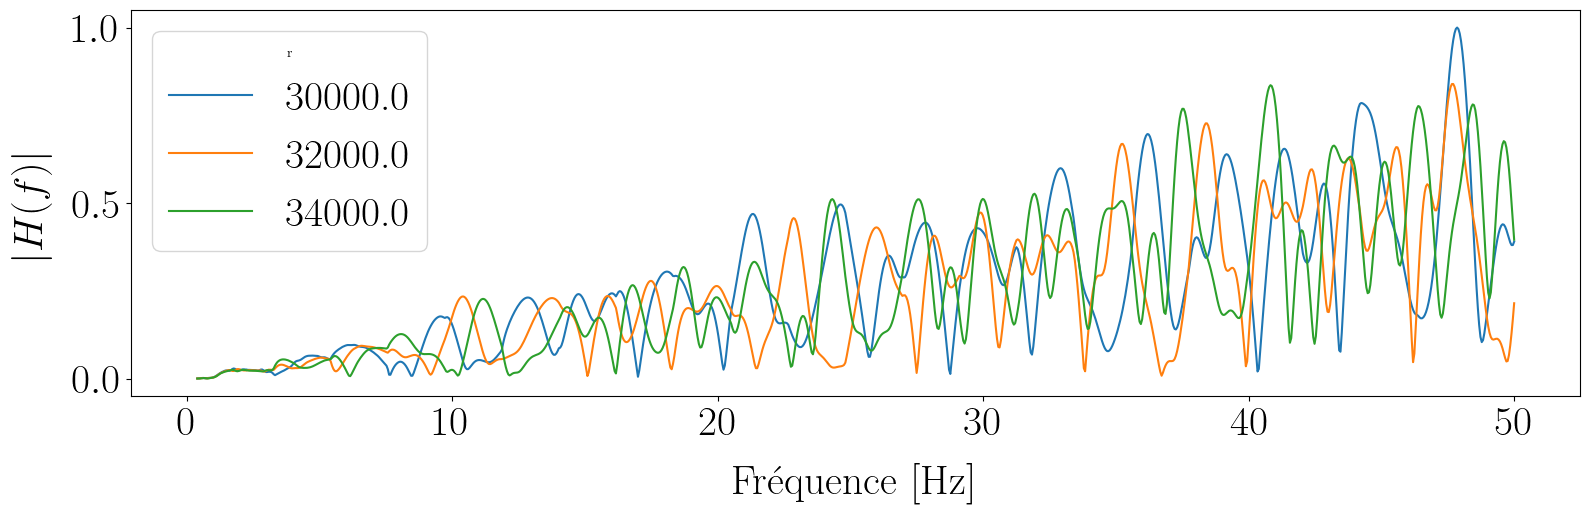

In [39]:
r_plot = 30 * 1e3
r_plot = r_plot + np.array([2000 * i for i in range(3)])

z_plot = 5
tf_pos = ds_tf.sel(r=r_plot, z=z_plot, method="nearest").tf_real + 1j * ds_tf.sel(r=r_plot, z=z_plot, method="nearest").tf_imag

tf_pos_mod = np.abs(tf_pos) / np.max(np.abs(tf_pos))

lfig = LargeFigure(language=language)
plt.figure()
tf_pos_mod.plot(x="f", hue="r")
plt.title("")
lfig.f_label.set_axis_label("x")
lfig.tfmod_label.set_axis_label("y")

# Save figure*
# fpath = os.path.join(img_folder_path, f"tf_r{r_plot*1e-3:.0f}km_z{z_plot:.0f}m.pdf")
# plt.savefig(fpath, dpi=300)

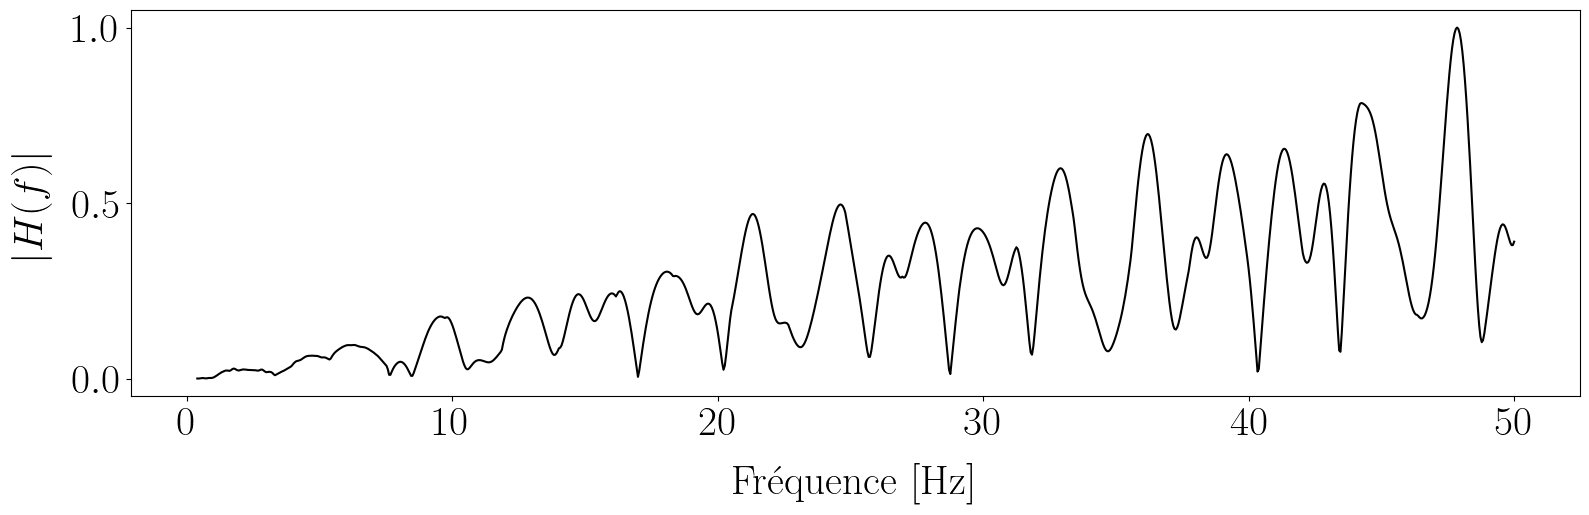

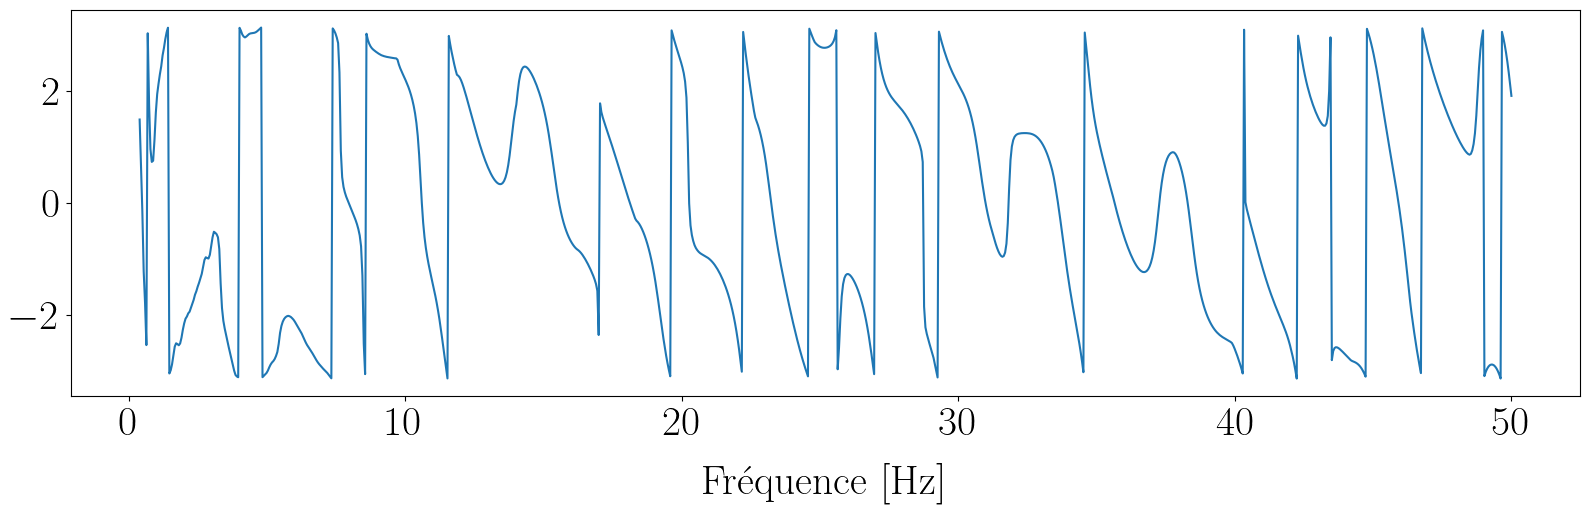

In [118]:
r_plot = 30 * 1e3

z_plot = 5
tf_pos = ds_tf.sel(r=r_plot, z=z_plot, method="nearest").tf_real + 1j * ds_tf.sel(r=r_plot, z=z_plot, method="nearest").tf_imag

k0 = 2 * np.pi * ds_tf.f.values / g.c0
norm_factor = np.exp(1j * k0) / (4 * np.pi)
tf_pos *= norm_factor


tf_pos_mod = np.abs(tf_pos) / np.max(np.abs(tf_pos))
tf_ang = np.angle(tf_pos)

lfig = LargeFigure(language=language)
plt.figure()
tf_pos_mod.plot(x="f", color="k")
plt.title("")
lfig.f_label.set_axis_label("x")
lfig.tfmod_label.set_axis_label("y")

# Save figure*
fpath = os.path.join(img_folder_path, f"tf_r{r_plot*1e-3:.0f}km_z{z_plot:.0f}m.pdf")
plt.savefig(fpath, dpi=300)

plt.figure()
plt.plot(tf_pos.f.values, tf_ang)
# tf_ang.plot(x="f", color="k")
plt.title("")
lfig.f_label.set_axis_label("x")
# lfig.tfphase_label.set_axis_label("y")

# # Save figure*
# fpath = os.path.join(img_folder_path, f"tf_r{r_plot*1e-3:.0f}km_z{z_plot:.0f}m_phase.pdf")
# plt.savefig(fpath, dpi=300)

# Génération des jeux de données pour chacun des cas test 

## Cas test 0 : démo avec un pulse 

In [41]:
# Extract testcase info
i_tc = 0
sig_name = testcase_infos[i_tc]["name"]
sig_fpath = testcase_infos[i_tc]["sig_fpath"]
hla_sig_fpath = testcase_infos[i_tc]["hla_sig_fpath"]

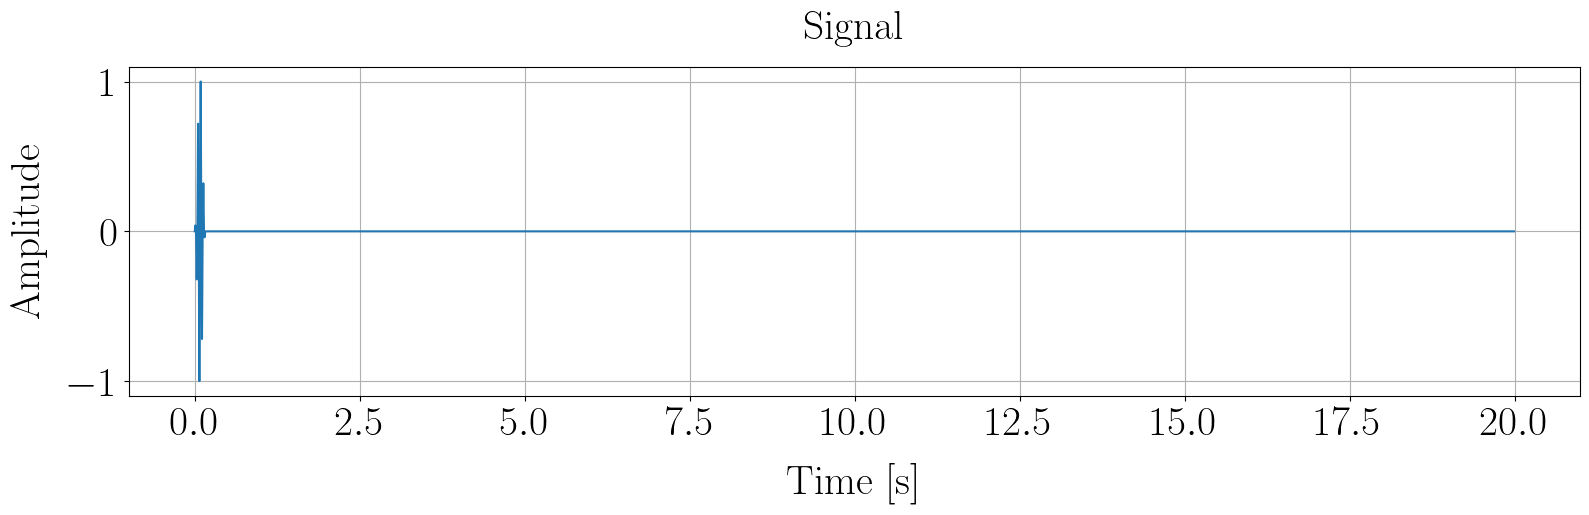

In [42]:
# Define source signal
fc = 25
s, t = sg.pulse(T=src_signal_duration, fc=fc, fs=src_fs, t0=0)
s = sg.normalize_sig(s, normalize="max")

# Plot time serie
sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="Pulse",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

<Figure size 1600x525 with 0 Axes>

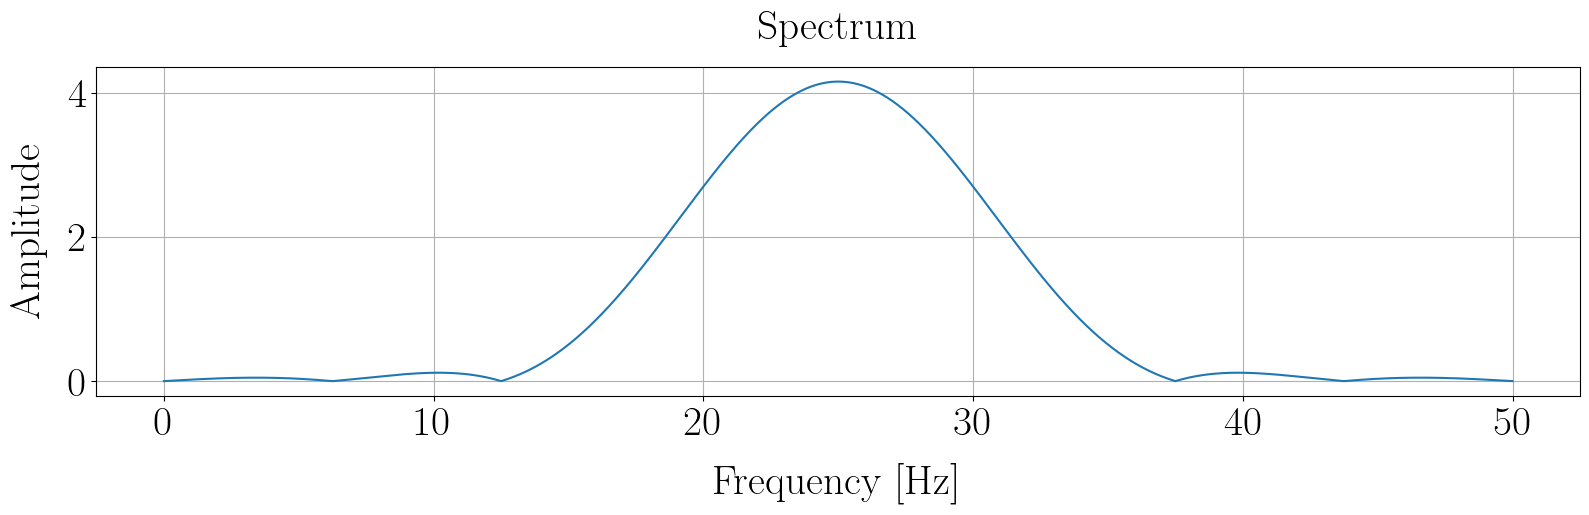

In [43]:
# Plot spectrum 
plt.figure()

sg.plot_spectrum(src.positive_freq, src.positive_spectrum)


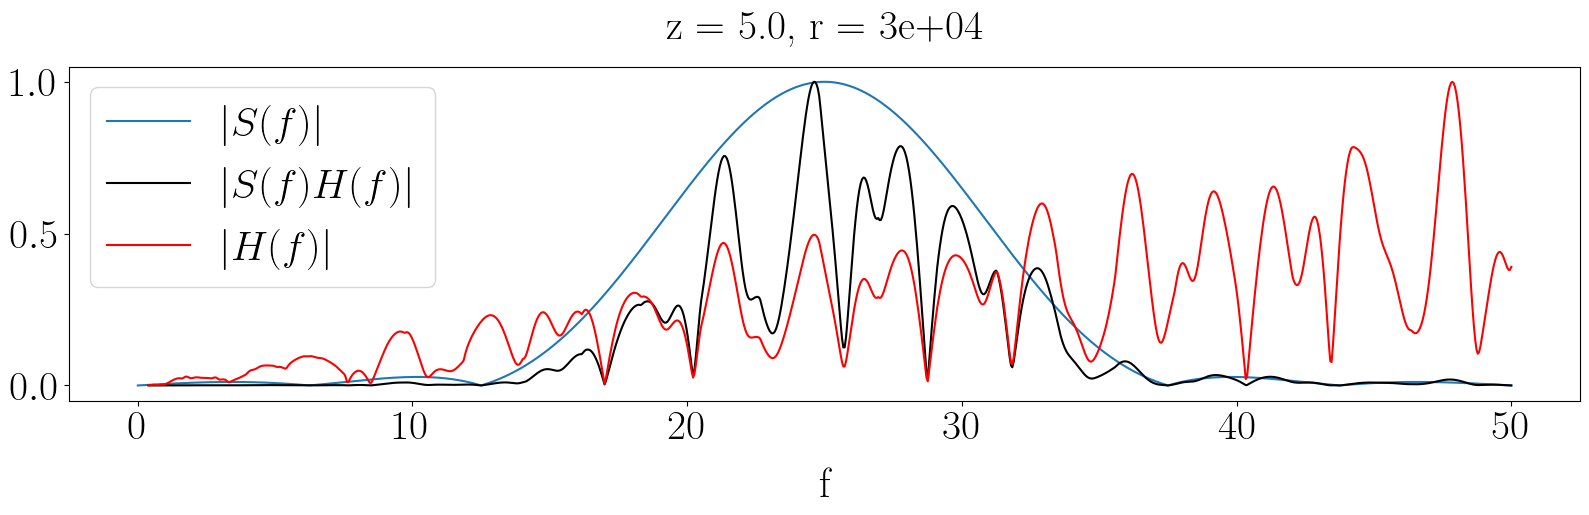

In [44]:
# Plot Sf * tf
Sf = src.positive_spectrum
fmin = np.min(ds_tf.f.values)
idx_first_freq = np.argmin(np.abs(src.positive_freq - fmin))
Sf = Sf[idx_first_freq:]
y_f = tf_pos * Sf

plt.figure()
plt.plot(
    src.positive_freq,
    np.abs(src.positive_spectrum) / np.max(np.abs(src.positive_spectrum)
                                           ),
    label="$|S(f)|$",
)
plt.plot(ds_tf.f, np.abs(y_f) / np.max(np.abs(y_f)), color="k", label="$|S(f)H(f)|$")
(np.abs(tf_pos) / np.max(np.abs(tf_pos))).plot(x="f", label=r"$|H(f)|$", color="r")
plt.legend()

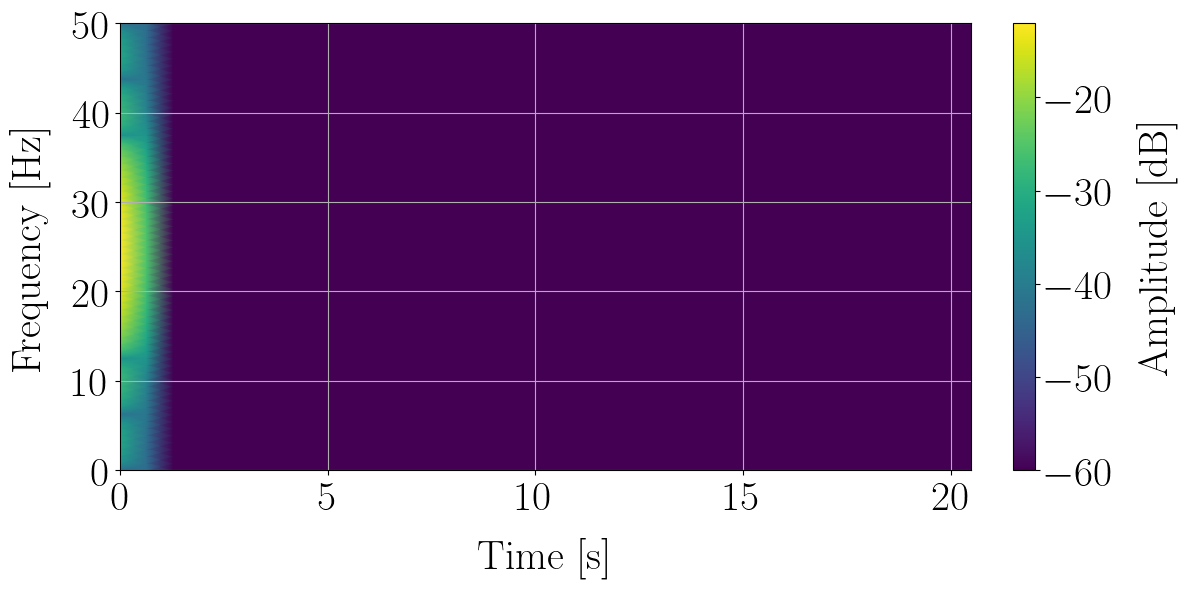

In [45]:
# Derive and plot STFT
window = "hann"
nperseg = 2**7
noverlap = 2**6
ff, tt, Sxx = sp.stft(
    s,
    fs=src_fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
)
Sxx[Sxx == 0] = 1e-6  # To avoid log of zero
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud")
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()

In [46]:
# Subsample transfer function dataset to reduce memory usage
rcv_rmin = ds_tf.r.min().values 
rcv_rmax = ds_tf.r.max().values
rcv_dr = 100
rcv_range = np.arange(rcv_rmin, rcv_rmax + rcv_dr, rcv_dr)

rcv_zmin = ds_tf.z.min().values
rcv_zmax = 200
rcv_dz = 10
rcv_depth = np.arange(rcv_zmin, rcv_zmax + rcv_dz, rcv_dz)

t, y_t, ds_sig = propagate_sig(tf_xr=ds_tf, src=src, rcv_range=rcv_range, rcv_depth=rcv_depth)

In [47]:
# Set dataset attributes and save it
ds_sig.attrs = {
    "fs": src_fs,
    "signal_duration": src_signal_duration,
    "source_type": "pulse",
}
# ds_sig.to_netcdf(sig_fpath)

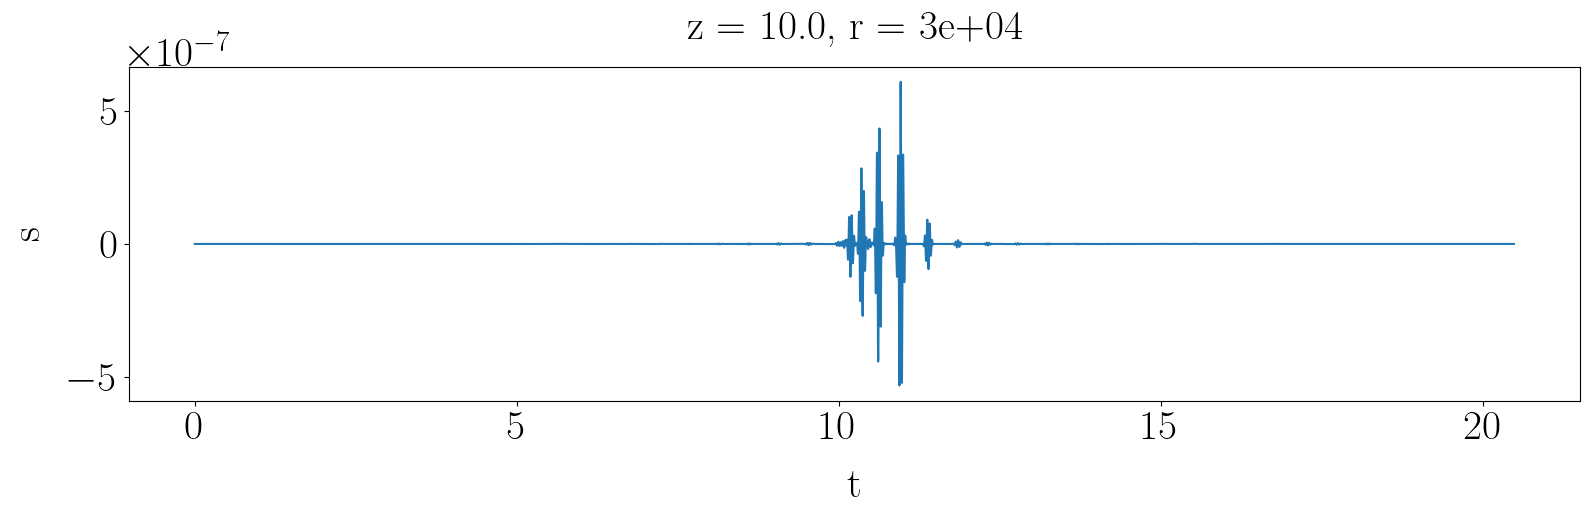

In [48]:
# Plot the propagated signal to check the result
lfig = LargeFigure()

r_plot = 30 * 1e3
z_plot = 10
ds_sig.sel(r=r_plot, z=z_plot).s.plot()

### Check every thing is ok 


(0.0, 50.0)

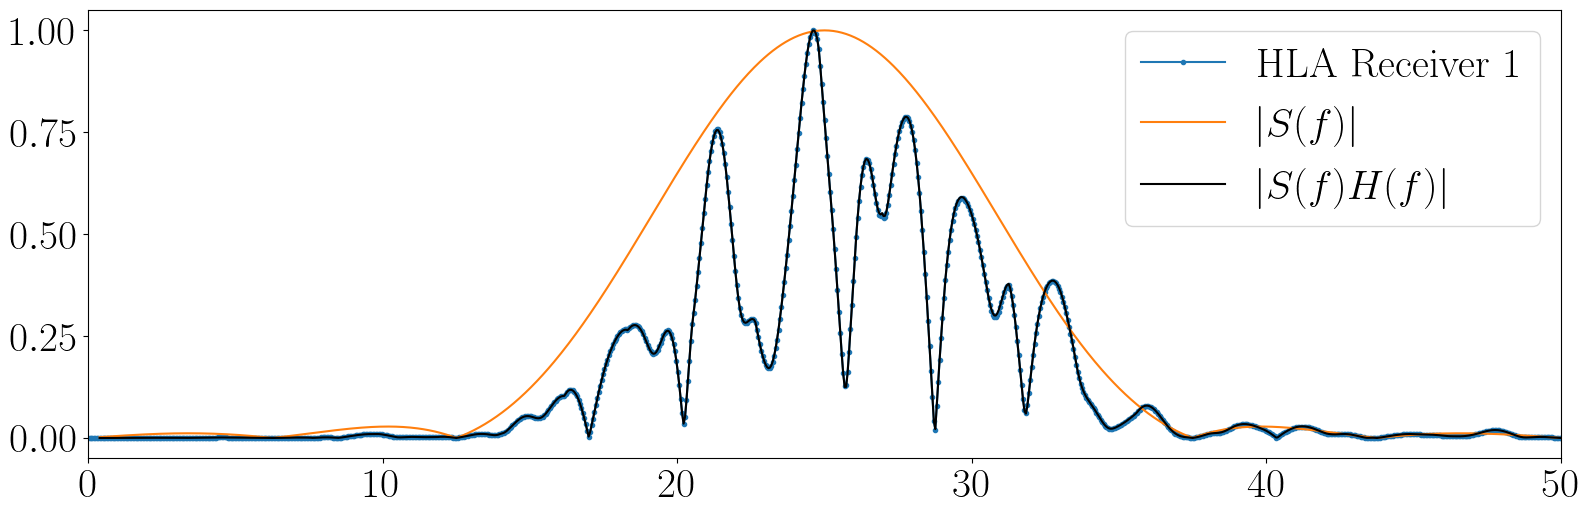

In [49]:
# Plot spectrums
r_plot = 30 * 1e3
z_plot = 10


# Sf * tf
Sf = src.positive_spectrum
fmin = np.min(ds_tf.f.values)
idx_first_freq = np.argmin(np.abs(src.positive_freq - fmin))
Sf = Sf[idx_first_freq:]
f_Sf = src.positive_freq[idx_first_freq:]
y_f = tf_pos * Sf

nfft_inv = 4 * src.nfft
ts = ds_sig.diff("t").t.values[0]

sig_0 = ds_sig.s.sel(r=r_plot, z=z_plot)
y_f_0 = np.fft.rfft(sig_0)
sig_0_f = np.fft.rfftfreq(sig_0.t.size, d=ts)


plt.figure()
plt.plot(sig_0_f, np.abs(y_f_0) / np.max(np.abs(y_f_0)), label="HLA Receiver 1", marker="o", markersize=3)
plt.plot(
    f_Sf,
    np.abs(Sf) / np.max(np.abs(Sf)),
    label="$|S(f)|$",
)
plt.plot(
    f_Sf,
    np.abs(y_f) / np.max(np.abs(y_f)),
    color="k",
    label="$|S(f)H(f)|$",
)

plt.legend()
plt.xlim([0,50]) 
# plt.ylim([-0.01,0.01])

(0.0, 50.0)

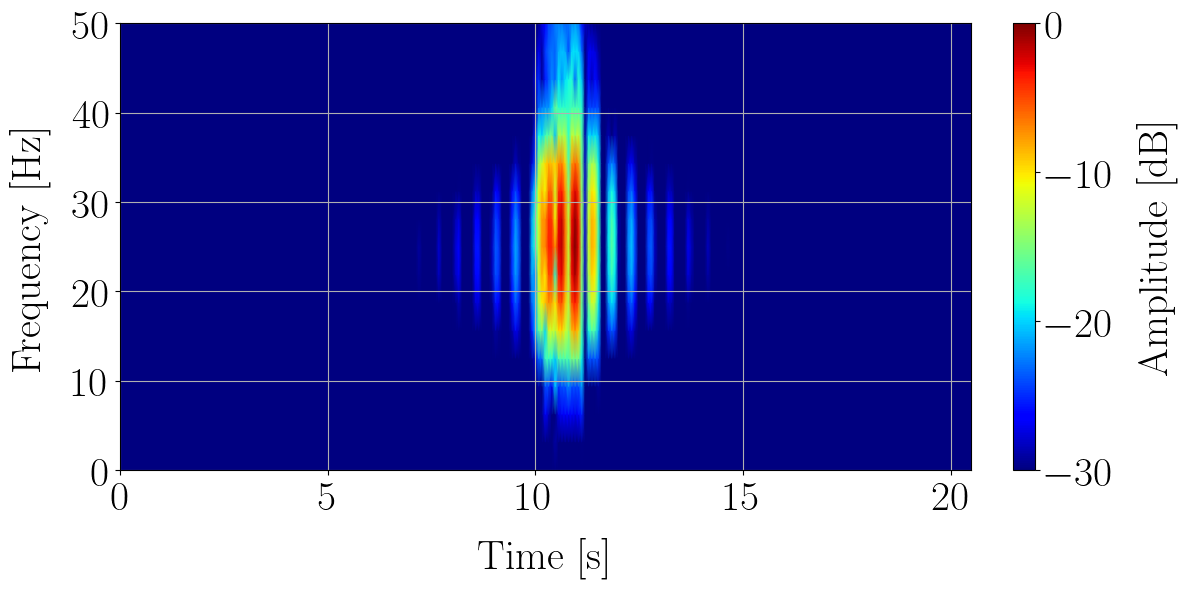

In [50]:
# Derive and plot STFT
window = "hann"
nperseg = 2**7
noverlap = nperseg * 3 // 4
ff, tt, Sxx = sp.stft(
    ds_sig.s.sel(r=r_plot, z=z_plot),
    fs=1/ts,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
)
Sxx /= np.max(np.abs(Sxx))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-30, vmax=-0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()
plt.ylim([0, 50])

In [51]:
run_this_section = False
# run_this_section = True

In [52]:
# hla_delta_r_rcv = 100  # Receiver range step in meters
hla_delta_r_rcv = 700  # Receiver range step in meters

hla_nrcv = 5  # Number of receivers in the HLA
if run_this_section:
    hla_sig_grid, hla_rtf_grid = build_hla_features(
        tf_xr=ds_tf,
        src=src,
        delta_r_rcv=hla_delta_r_rcv,
        rcv_range=rcv_range,
        rcv_depth=rcv_depth,
        n_rcv=hla_nrcv,
        rmin=None,
        rmax=None,
        z_src=src_depth     
    )

    # Get output fs
    z_ts = hla_sig_grid.diff("t").t.values[0]
    z_fs = 1 / z_ts

    # Save HLA features
    hla_sig_grid.attrs = {
        "fs": z_fs,
        "signal_duration": src_signal_duration,
        "source_type": sig_name,
        "antenna": "HLA",
        "delta_r_rcv": hla_delta_r_rcv,
        "n_rcv": hla_nrcv,
        "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
    }
    hla_rtf_grid.attrs = {
        "fs": src_fs,
        "signal_duration": src_signal_duration,
        "antenna": "HLA",
        "delta_r_rcv": hla_delta_r_rcv,
        "n_rcv": hla_nrcv,
        "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
    }
    hla_sig_grid.to_netcdf(hla_sig_fpath)
    hla_rtf_grid.to_netcdf(hla_rtf_fpath)

else:
    # load pre-existing datasets
    hla_sig_grid = xr.open_dataset(hla_sig_fpath)
    hla_rtf_grid = xr.open_dataset(hla_rtf_fpath)

    z_fs = hla_sig_grid.fs

## Plot received signals 

Text(0, 0.5, 'Amplitude')

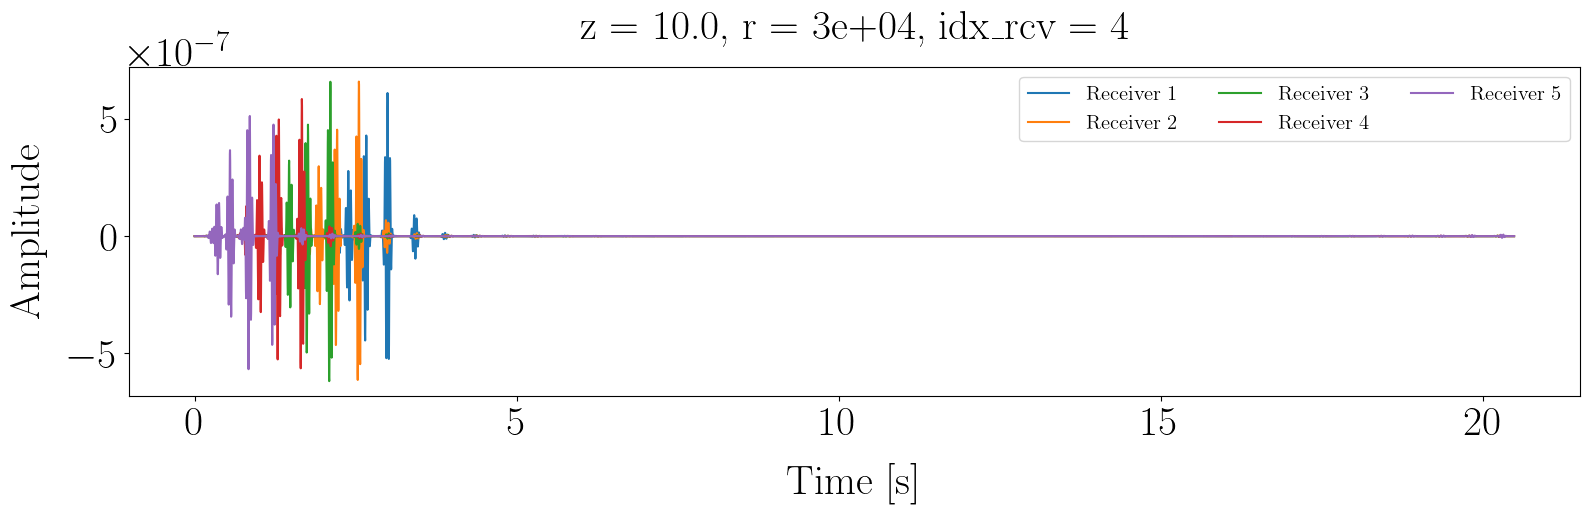

In [53]:
# Visualize signals at each receiver
r_plot = 30 * 1e3
z_plot = 10

lfig = LargeFigure()
plt.figure()
for i in range(hla_nrcv):
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=i).plot(label=f"Receiver {i+1}")
# plt.xlim([0, 5])
plt.legend(ncols=3, fontsize=15)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

(0.0, 50.0)

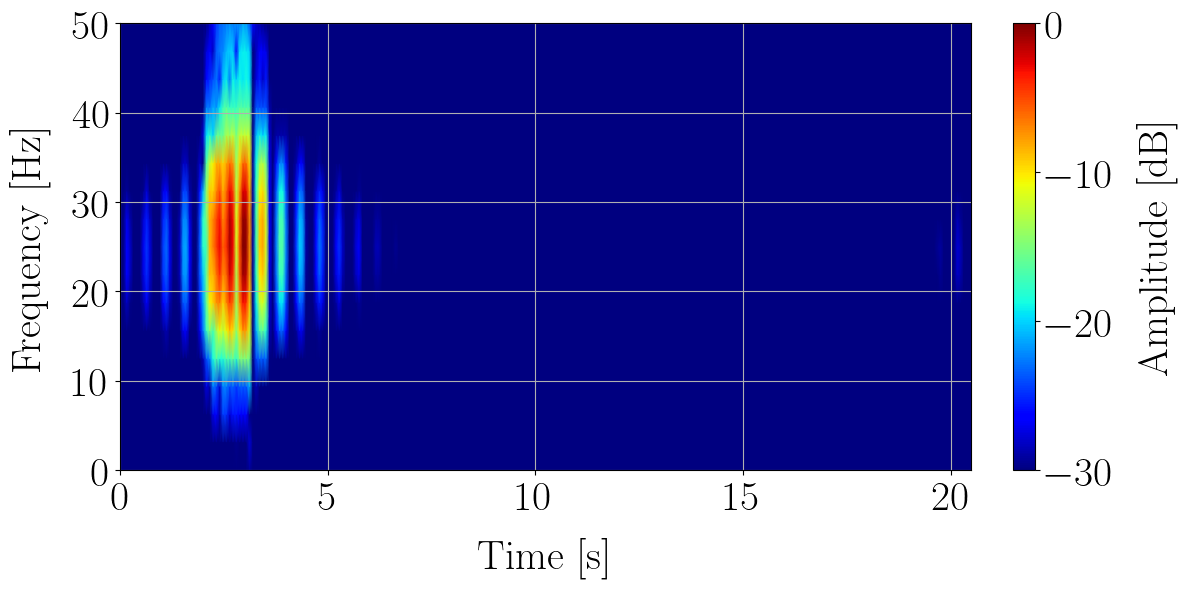

In [54]:
# Derive and plot STFT
window = "hann"
nperseg = 2**7
noverlap = 2**7 * 3//4
ff, tt, Sxx = sp.stft(
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=0),
    fs=z_fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
)
Sxx /= np.max(np.abs(Sxx))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-30, vmax=-0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()
plt.ylim([0, 50])
# plt.xlim([0, 10])

(0.0, 50.0)

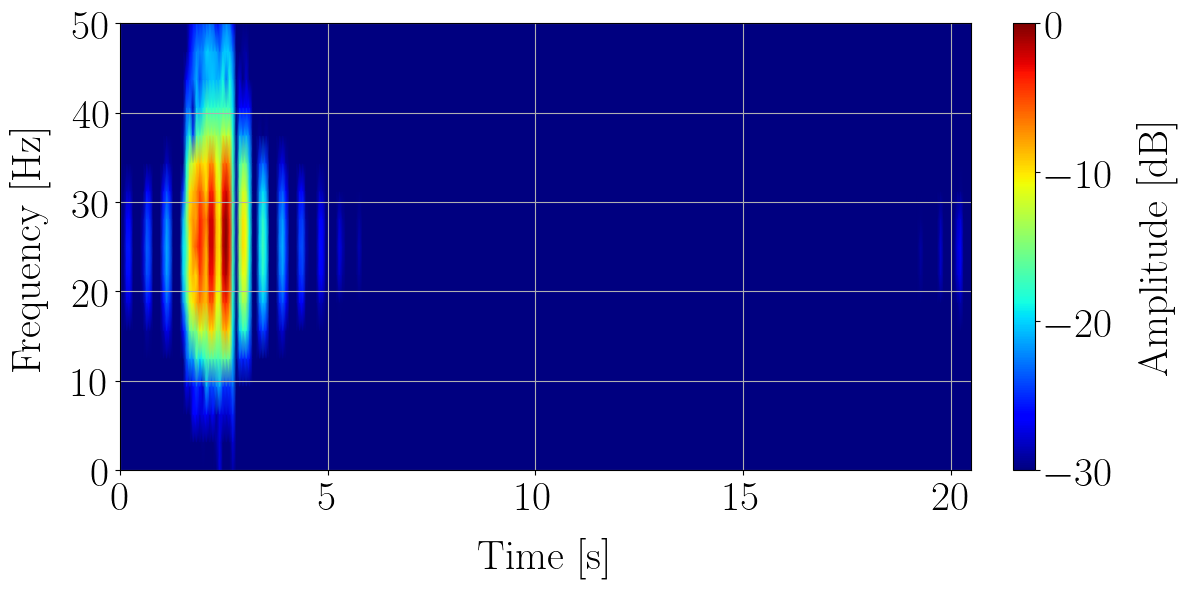

In [55]:
# Derive and plot STFT
window = "hann"
nperseg = 2**7
noverlap = 2**7 * 3//4
ff, tt, Sxx = sp.stft(
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=1),
    fs=z_fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
)
Sxx /= np.max(np.abs(Sxx))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-30, vmax=-0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()
plt.ylim([0, 50])
# plt.xlim([0, 10])

## Plot associated RTF (true) 

In [56]:
lfig = LargeFigure(language=language)

hla_rtf_pos = hla_rtf_grid.rtf_real.sel(r=r_plot, z=z_plot, method="nearest") + 1j * hla_rtf_grid.rtf_imag.sel(r=r_plot, z=z_plot, method="nearest")

plt.figure()
for i in range(hla_nrcv):
    np.abs(hla_rtf_pos.sel(idx_rcv=i)).plot(label=r"$\Pi_{" + str(i) + r"}^{(Kraken)}$"),

# plt.xscale()
plt.yscale("log")
lfig.f_label.set_axis_label("x")
lfig.rtfmod_label.set_axis_label("y")
plt.legend(fontsize=16, ncols=3)
plt.title(f"Range = {r_plot/1e3} km, Depth = {z_plot} m")

# Save figure 
# fpath = os.path.join()
# plt.savefig(fpath, dpi=300)

KeyError: "not all values found in index 'z'. Try setting the `method` keyword argument (example: method='nearest')."

## Cas test 1 : bruit blanc 

In [57]:
# Extract testcase info
i_tc = 1
sig_name = testcase_infos[i_tc]["name"]
sig_fpath = testcase_infos[i_tc]["sig_fpath"]
hla_sig_fpath = testcase_infos[i_tc]["hla_sig_fpath"]

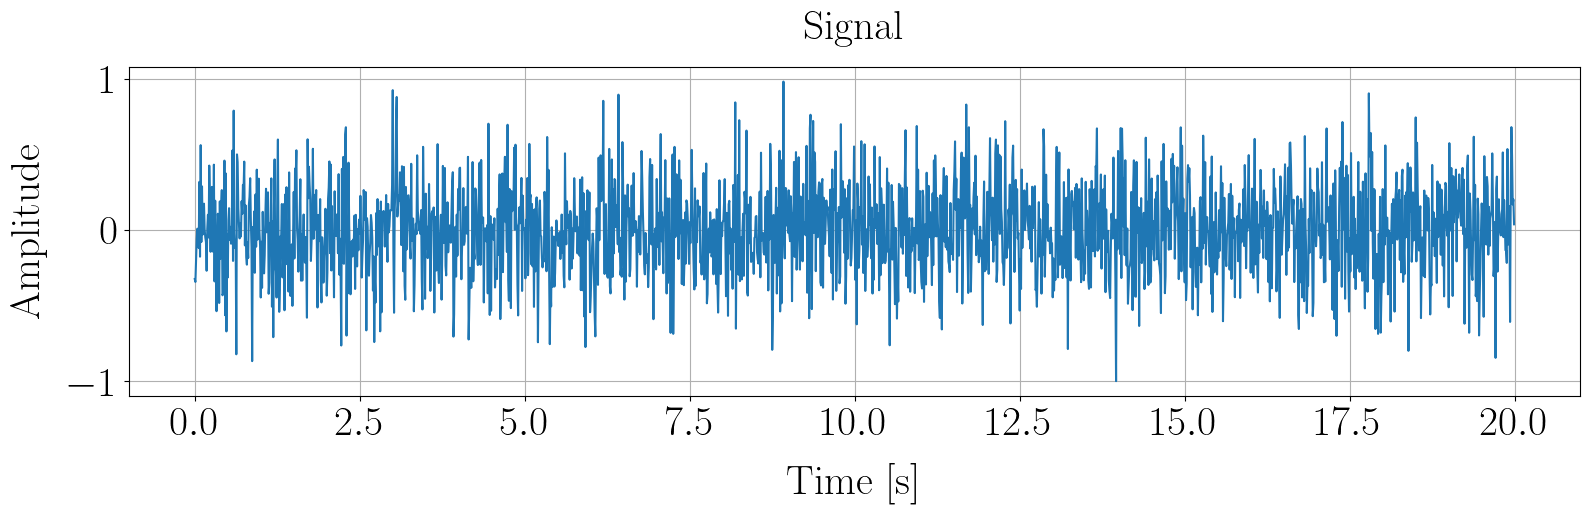

In [58]:
# Define source signal
t, s = sg.colored_noise(T=src_signal_duration, fs=src_fs, noise_color="white")
# t, s = sg.colored_noise(T=2000, fs=src_fs, noise_color="white")

s = sg.normalize_sig(s, normalize="max")
# Plot time serie
sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="White noise",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

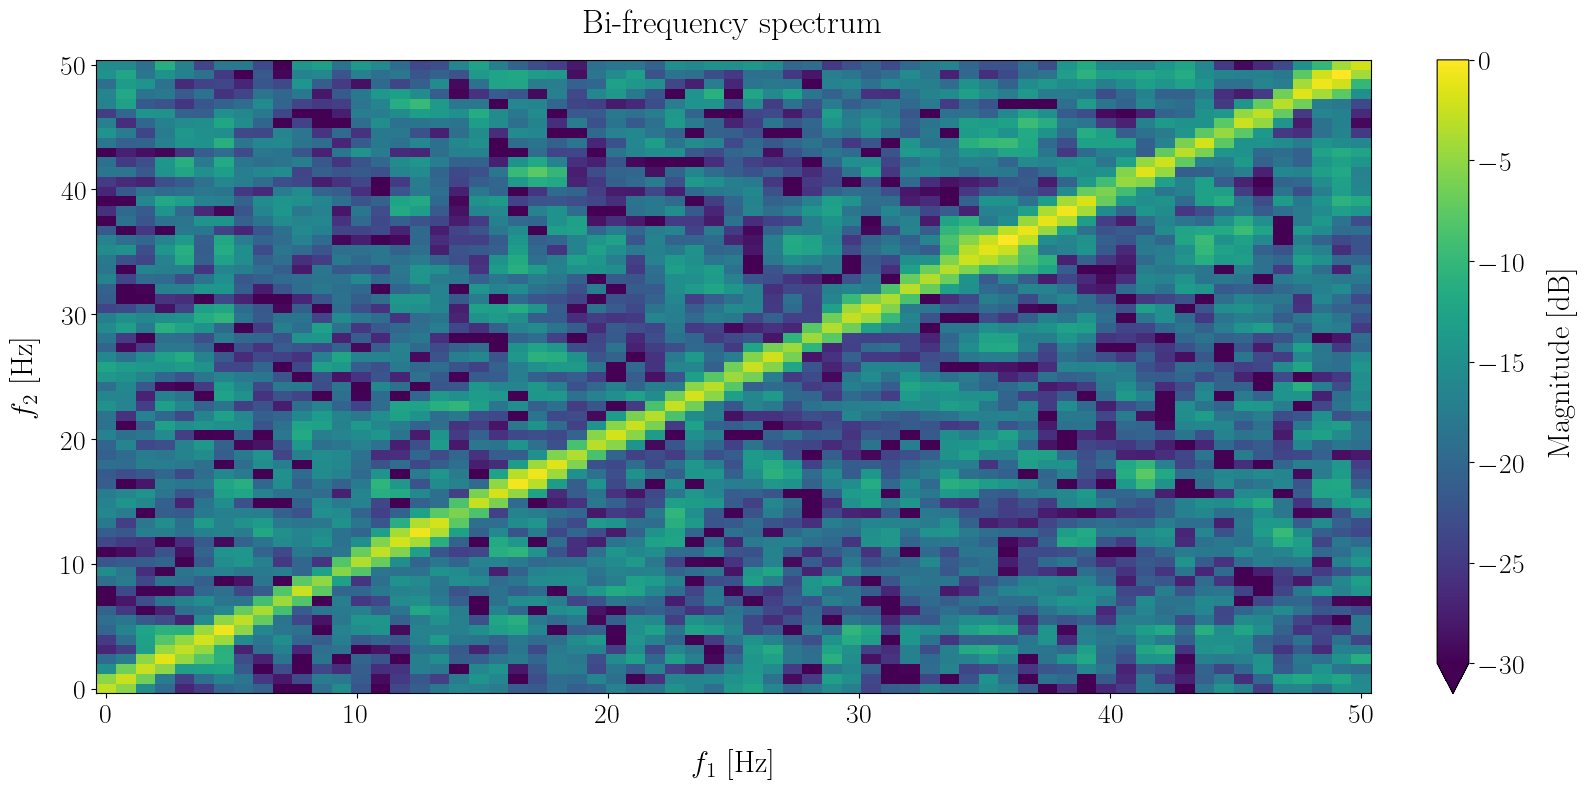

In [59]:
# Bifreq spectrum
from real_data_analysis.signal_processing_utils import get_bifrequency_spectrum

ff, S_f1f2 = get_bifrequency_spectrum(
    s=s,
    fs=src_fs,
    fmin=0,
    fmax=50,
    nperseg=2**7,
    noverlap=2**6,
    plot=True,
    root_img=img_folder_path,
    
)

In [60]:
# hla_delta_r_rcv = 100  # Receiver range step in meters
# hla_nrcv = 5  # Number of receivers in the HLA
hla_sig_grid, _ = build_hla_features(
    tf_xr=ds_tf,
    src=src,
    delta_r_rcv=hla_delta_r_rcv,
    rcv_range=rcv_range,
    rcv_depth=rcv_depth,
    n_rcv=hla_nrcv,
    rmin=None,
    rmax=None,
)

# Get output fs
z_ts = hla_sig_grid.diff("t").t.values[0]
z_fs = 1 / z_ts

Text(0, 0.5, 'Amplitude')

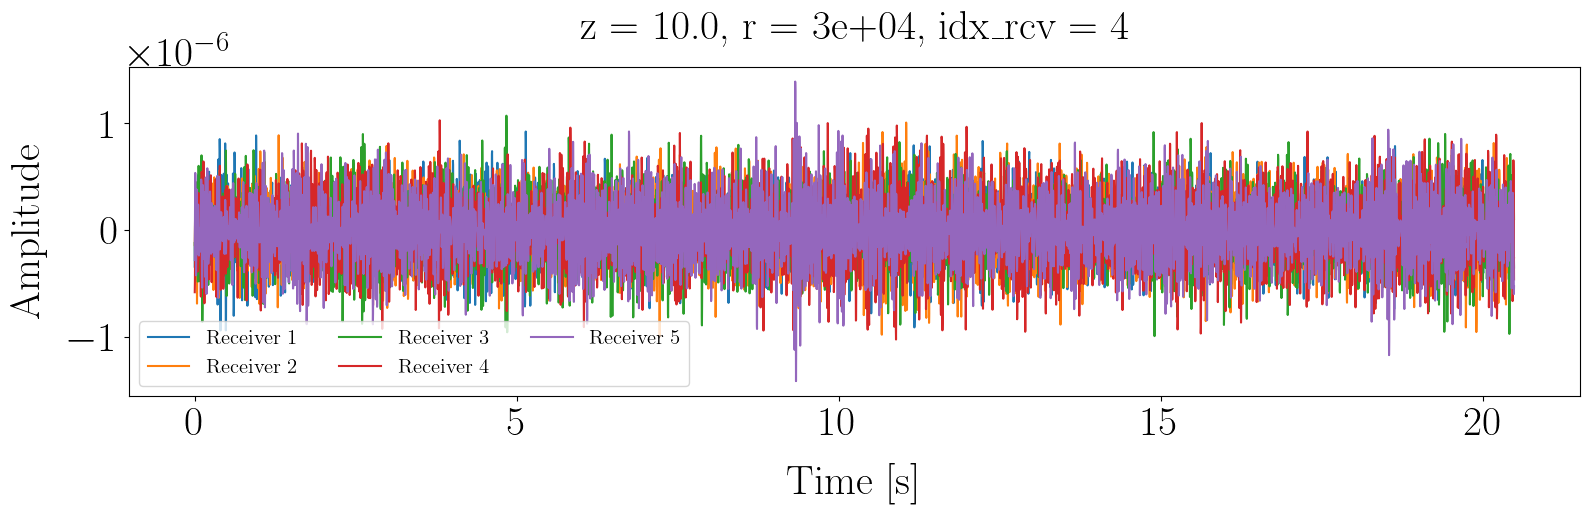

In [61]:
# Visualize signals at each receiver
r_plot = 30 * 1e3
z_plot = 10

lfig = LargeFigure()
plt.figure()
for i in range(hla_nrcv):
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=i).plot(label=f"Receiver {i+1}")
# plt.xlim([9.5, 11.5])
plt.legend(ncols=3, fontsize=15)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

In [62]:
# Save HLA features
hla_sig_grid.attrs = {
    "fs": z_fs,
    "signal_duration": src_signal_duration,
    "source_type": sig_name,
    "antenna": "HLA",
    "delta_r_rcv": hla_delta_r_rcv,
    "n_rcv": hla_nrcv,
    "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
}
hla_sig_grid.to_netcdf(hla_sig_fpath)

## Cas test 2 : pink noise

In [63]:
# Extract testcase info
i_tc = 2
sig_name = testcase_infos[i_tc]["name"]
sig_fpath = testcase_infos[i_tc]["sig_fpath"]
hla_sig_fpath = testcase_infos[i_tc]["hla_sig_fpath"]

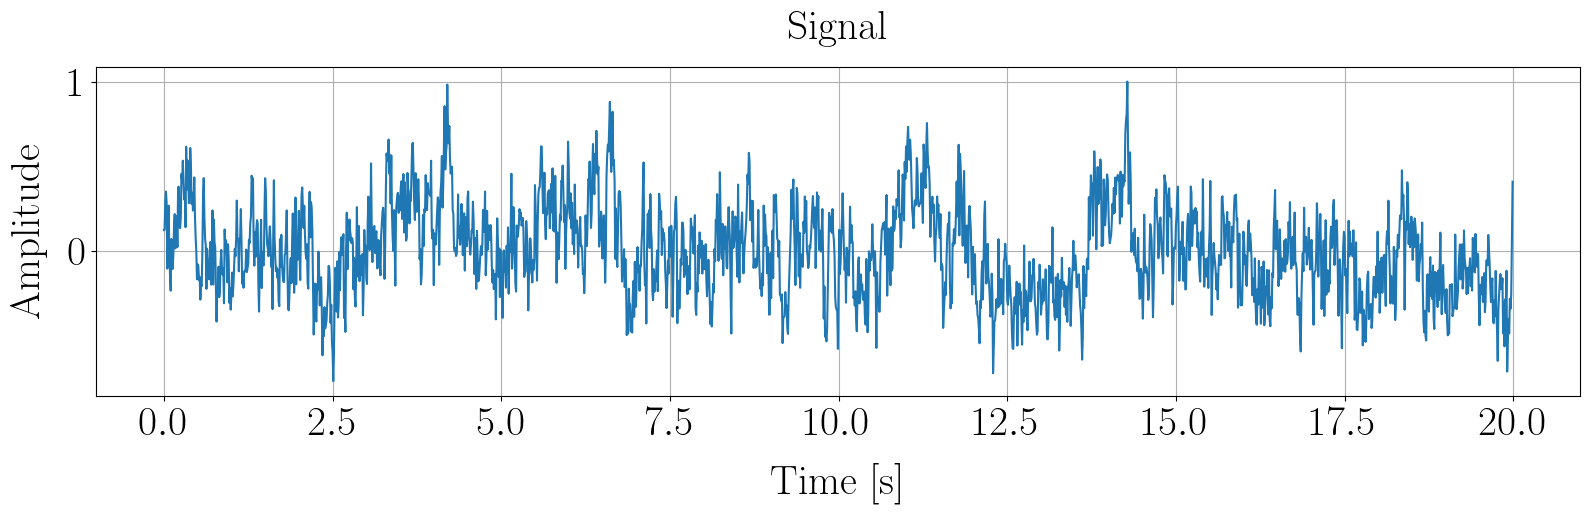

In [64]:
# Define source signal
fc = 25
t, s = sg.colored_noise(T=src_signal_duration, fs=src_fs, noise_color="pink")
s = sg.normalize_sig(s, normalize="max")
# Plot time serie
sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="Pink noise",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

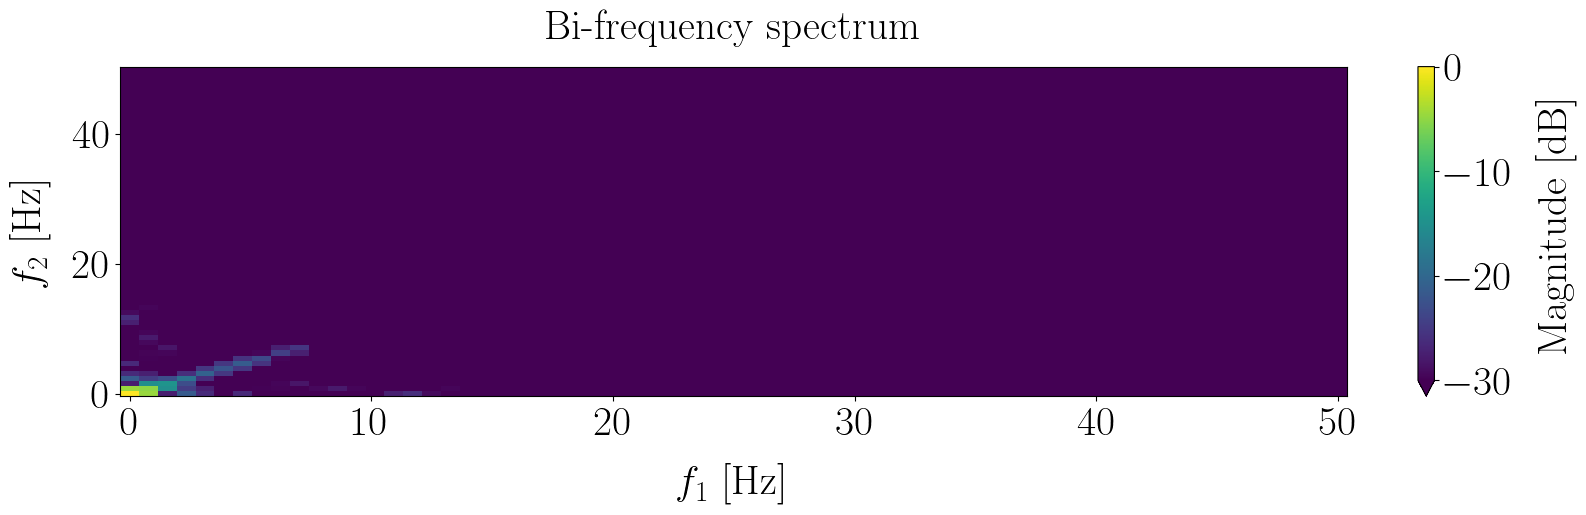

In [65]:
# Bifreq spectrum
ff, S_f1f2 = get_bifrequency_spectrum(
    s=s,
    fs=src_fs,
    fmin=0,
    fmax=50,
    nperseg=2**7,
    noverlap=2**6,
    plot=True,
    root_img=img_folder_path,
)

In [66]:
# hla_delta_r_rcv = 100  # Receiver range step in meters
hla_nrcv = 5  # Number of receivers in the HLA
hla_sig_grid, _ = build_hla_features(
    tf_xr=ds_tf,
    src=src,
    delta_r_rcv=hla_delta_r_rcv,
    rcv_range=rcv_range,
    rcv_depth=rcv_depth,
    n_rcv=hla_nrcv,
    rmin=None,
    rmax=None,
)

# Get output fs
z_ts = hla_sig_grid.diff("t").t.values[0]
z_fs = 1 / z_ts

Text(0, 0.5, 'Amplitude')

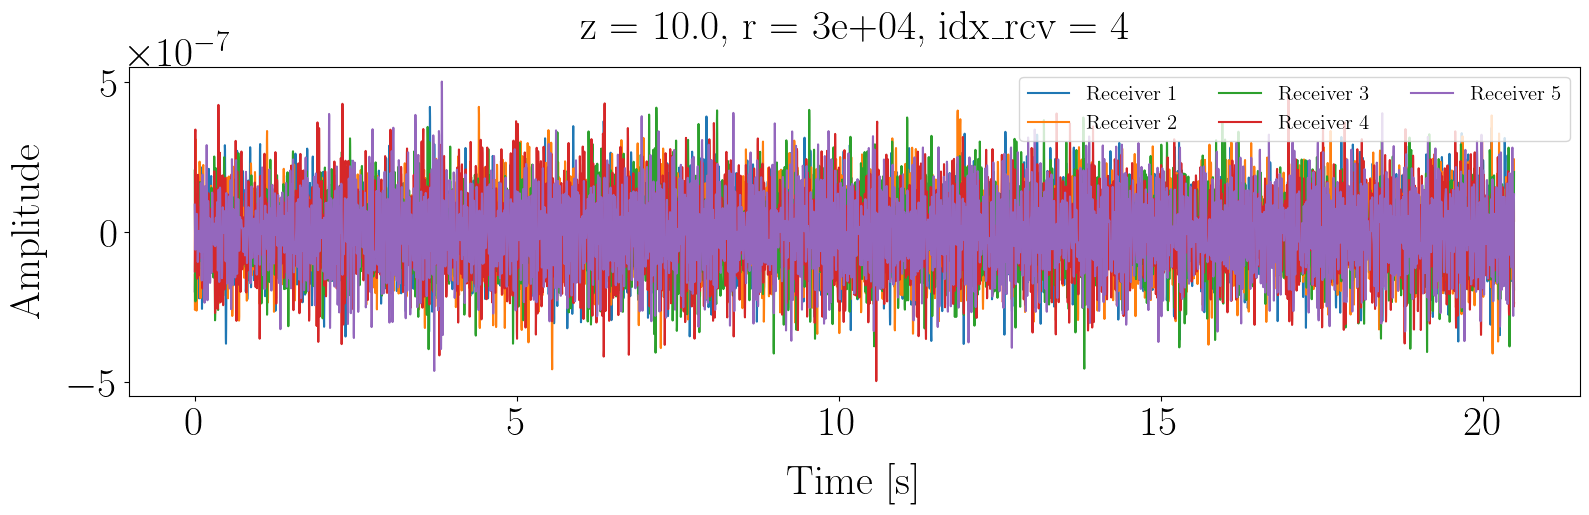

In [67]:
# Visualize signals at each receiver
r_plot = 30 * 1e3
z_plot = 10

lfig = LargeFigure()
plt.figure()
for i in range(hla_nrcv):
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=i).plot(label=f"Receiver {i+1}")
# plt.xlim([9.5, 11.5])
plt.legend(ncols=3, fontsize=15)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

In [68]:
# Save HLA features
hla_sig_grid.attrs = {
    "fs": z_fs,
    "signal_duration": src_signal_duration,
    "source_type": sig_name,
    "antenna": "HLA",
    "delta_r_rcv": hla_delta_r_rcv,
    "n_rcv": hla_nrcv,
    "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
}
hla_sig_grid.to_netcdf(hla_sig_fpath)

## Cas test 3 : LFM

In [69]:
# Extract testcase info
i_tc = 3
sig_name = testcase_infos[i_tc]["name"]
sig_fpath = testcase_infos[i_tc]["sig_fpath"]
hla_sig_fpath = testcase_infos[i_tc]["hla_sig_fpath"]

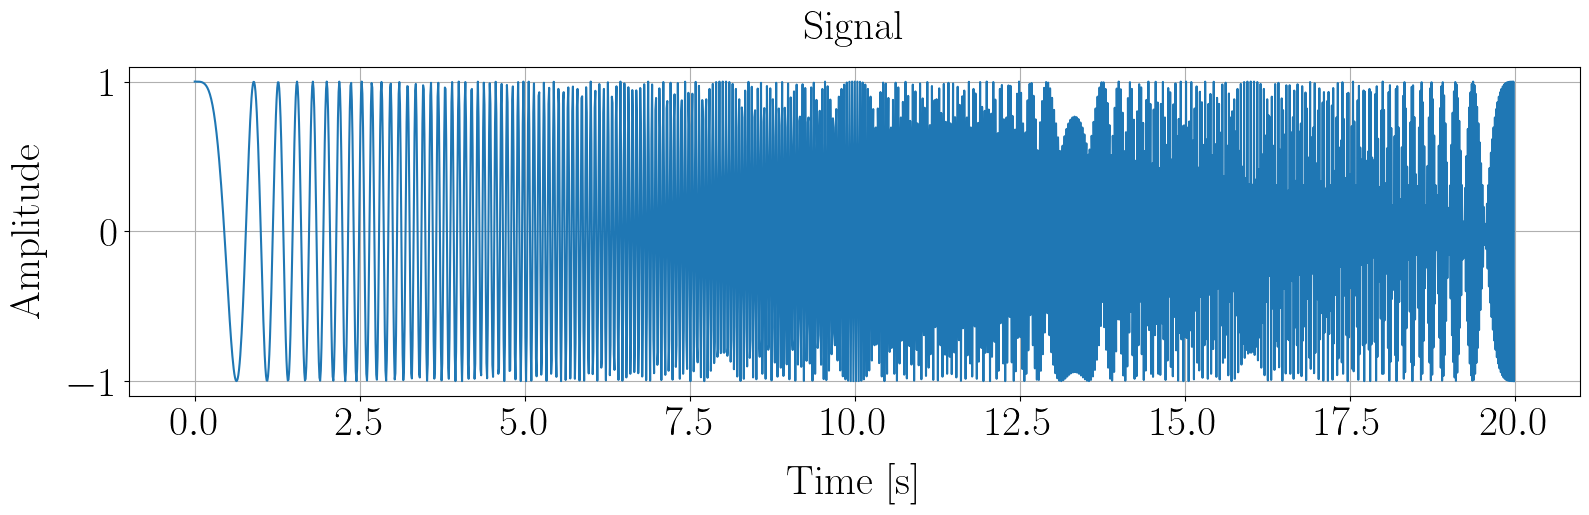

In [70]:
# Define source signal
f0 = 0
f1 = 50
t, s = sg.lfm_chirp(f0=f0, f1=f1, fs=src_fs, T=src_signal_duration, phi=0)

s = sg.normalize_sig(s, normalize="max")
# Plot time serie
sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="Chirp LFM",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

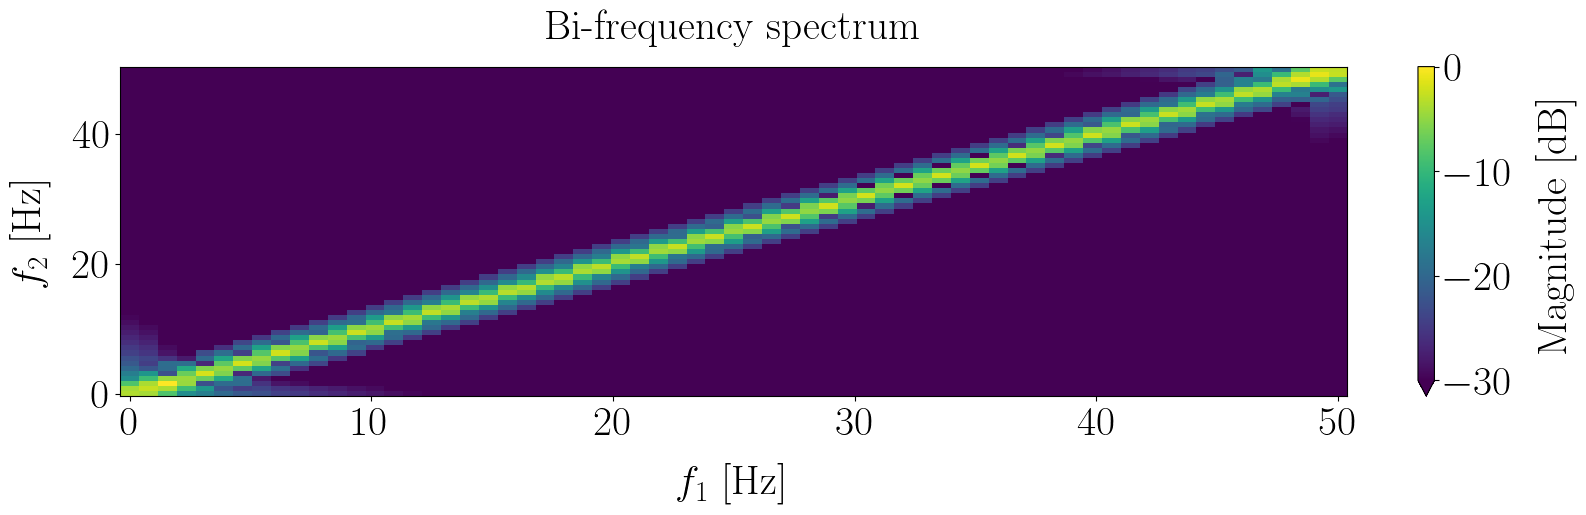

In [71]:
# Bifreq spectrum
ff, S_f1f2 = get_bifrequency_spectrum(
    s=s,
    fs=src_fs,
    fmin=0,
    fmax=50,
    nperseg=2**7,
    noverlap=2**6,
    plot=True,
    root_img=img_folder_path,
)

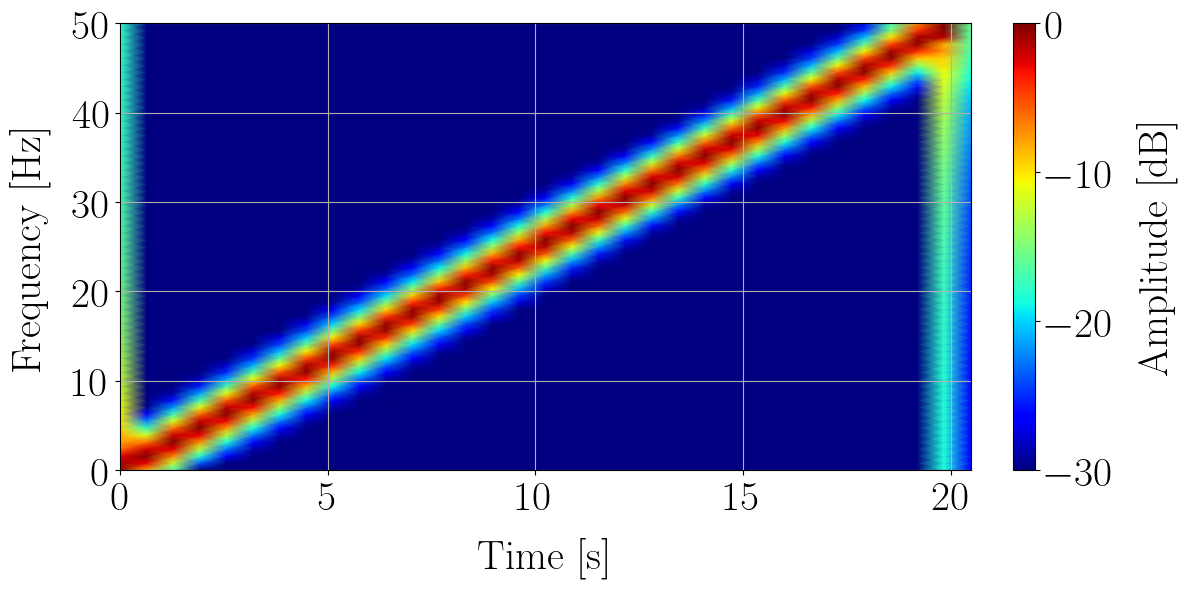

In [72]:
# Derive and plot STFT
window="hann"
nperseg=2**7
noverlap=2**6
ff, tt, Sxx = sp.stft(
    s, fs=src_fs, window=window, nperseg=nperseg, noverlap=noverlap
)

Sxx /= np.max(np.abs(Sxx))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-30, vmax=-0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()


In [73]:
# hla_delta_r_rcv = 100  # Receiver range step in meters
hla_nrcv = 5  # Number of receivers in the HLA
hla_sig_grid, _ = build_hla_features(
    tf_xr=ds_tf,
    src=src,
    delta_r_rcv=hla_delta_r_rcv,
    rcv_range=rcv_range,
    rcv_depth=rcv_depth,
    n_rcv=hla_nrcv,
    rmin=None,
    rmax=None,
)

# Get output fs
z_ts = hla_sig_grid.diff("t").t.values[0]
z_fs = 1 / z_ts

Text(0, 0.5, 'Amplitude')

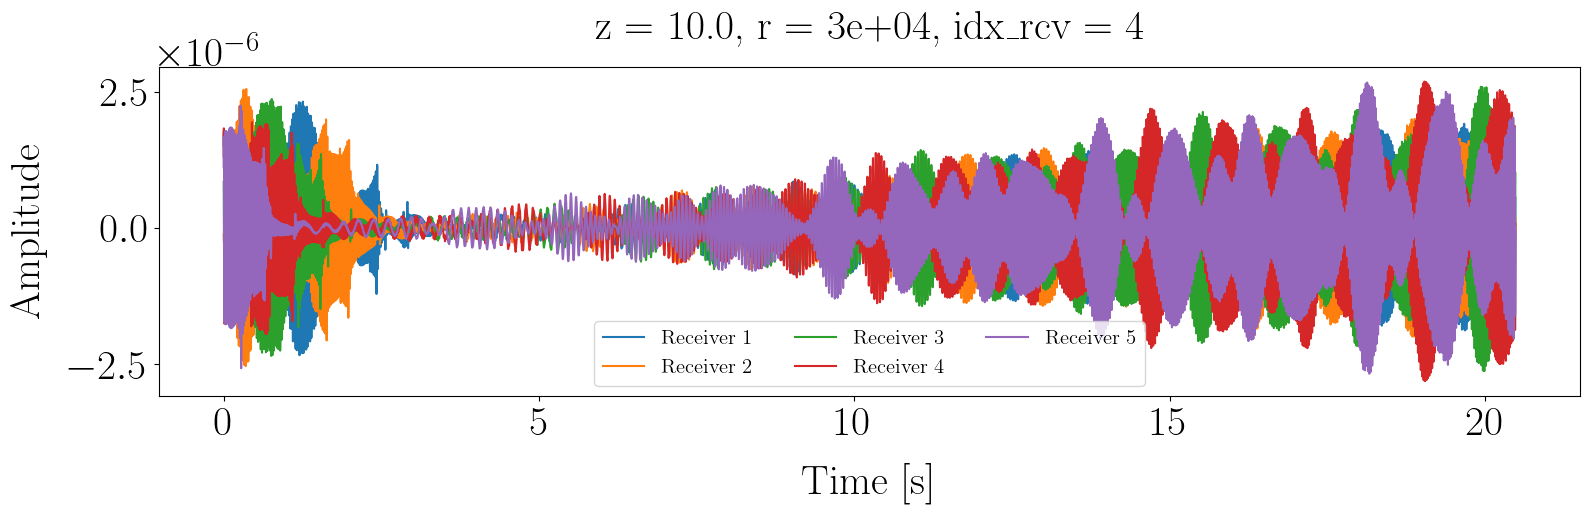

In [74]:
# Visualize signals at each receiver
r_plot = 30 * 1e3
z_plot = 10

lfig = LargeFigure()
plt.figure()
for i in range(hla_nrcv):
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=i).plot(label=f"Receiver {i+1}")
# plt.xlim([9.5, 11.5])
plt.legend(ncols=3, fontsize=15)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

In [75]:
# Save HLA features
hla_sig_grid.attrs = {
    "fs": z_fs,
    "signal_duration": src_signal_duration,
    "source_type": sig_name,
    "antenna": "HLA",
    "delta_r_rcv": hla_delta_r_rcv,
    "n_rcv": hla_nrcv,
    "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
}
hla_sig_grid.to_netcdf(hla_sig_fpath)

(0.0, 50.0)

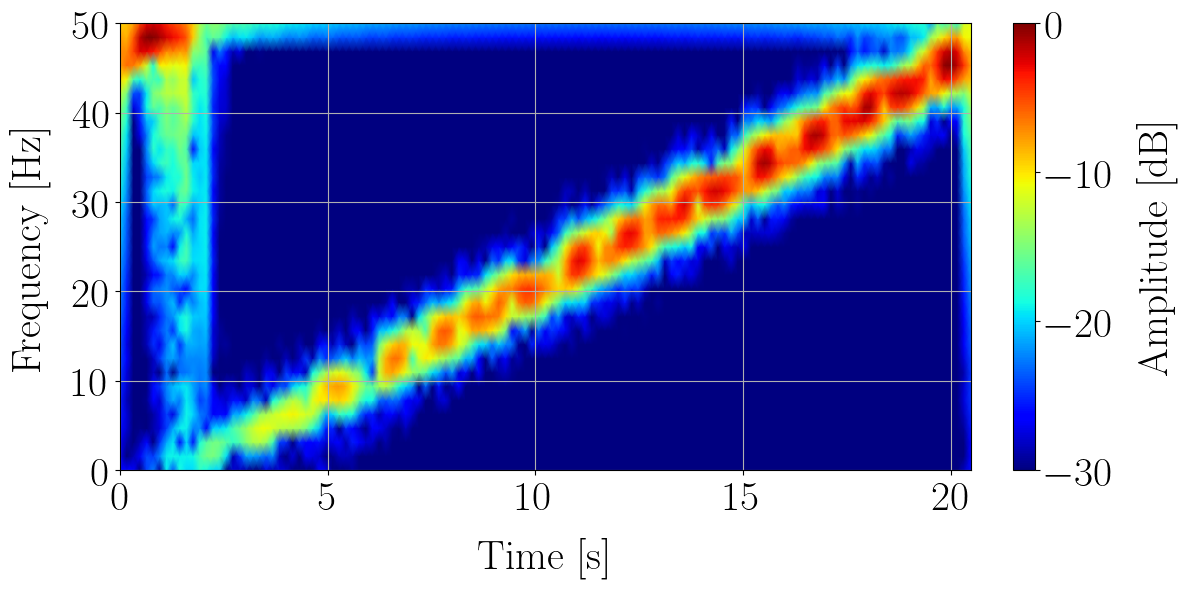

In [76]:
# Derive and plot STFT
window="hann"
nperseg=2**8
noverlap=nperseg * 3//4
ff, tt, Sxx = sp.stft(
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=2),
    fs=z_fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
)
Sxx /= np.max(np.abs(Sxx))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-30, vmax=-0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()
plt.ylim([0, 50])

## Cas test 4 : train de LFM

In [77]:
# Extract testcase info
i_tc = 4
sig_name = "lfm_train"
sig_fpath = os.path.join(data_folder_path, f"sig_{sig_name}.nc")
hla_sig_fpath = os.path.join(data_folder_path, f"hla_sig_{sig_name}.nc")
testcase_infos[i_tc] = {"name": sig_name,  
                        "sig_fpath": sig_fpath,
                        "hla_sig_fpath": hla_sig_fpath
                        }

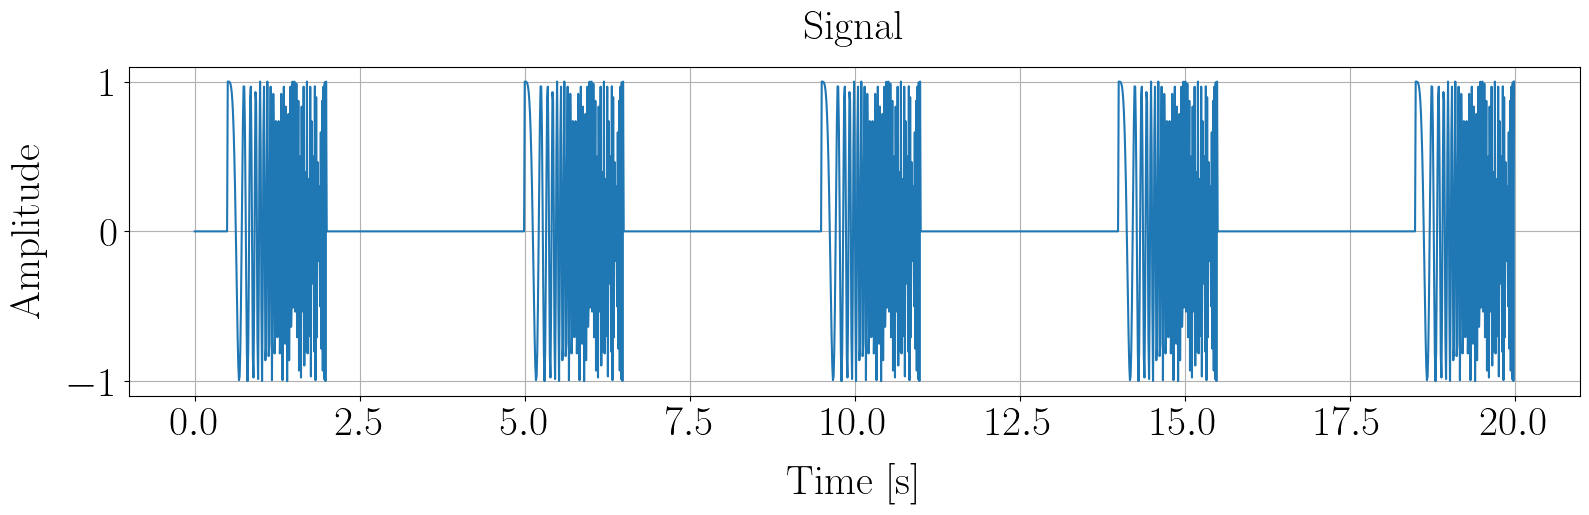

In [78]:
# Define source signal
f0 = 0
f1 = 50
# nchirp = 10
T_chirp = 1.5
interpulse_delay = 3 
s, t = sg.lfm_chirp_train(
    f0,
    f1,
    fs=src_fs,
    T_chirp=T_chirp,
    T=src_signal_duration,
    interpulse_delay=interpulse_delay,
    start_delay=0.5,
)
# t, s = sg.lfm_chirp(f0=f0, f1=f1, fs=src_fs, T=src_signal_duration, phi=0)

s = sg.normalize_sig(s, normalize="max")
# Plot time serie
sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="Chirp LFM",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

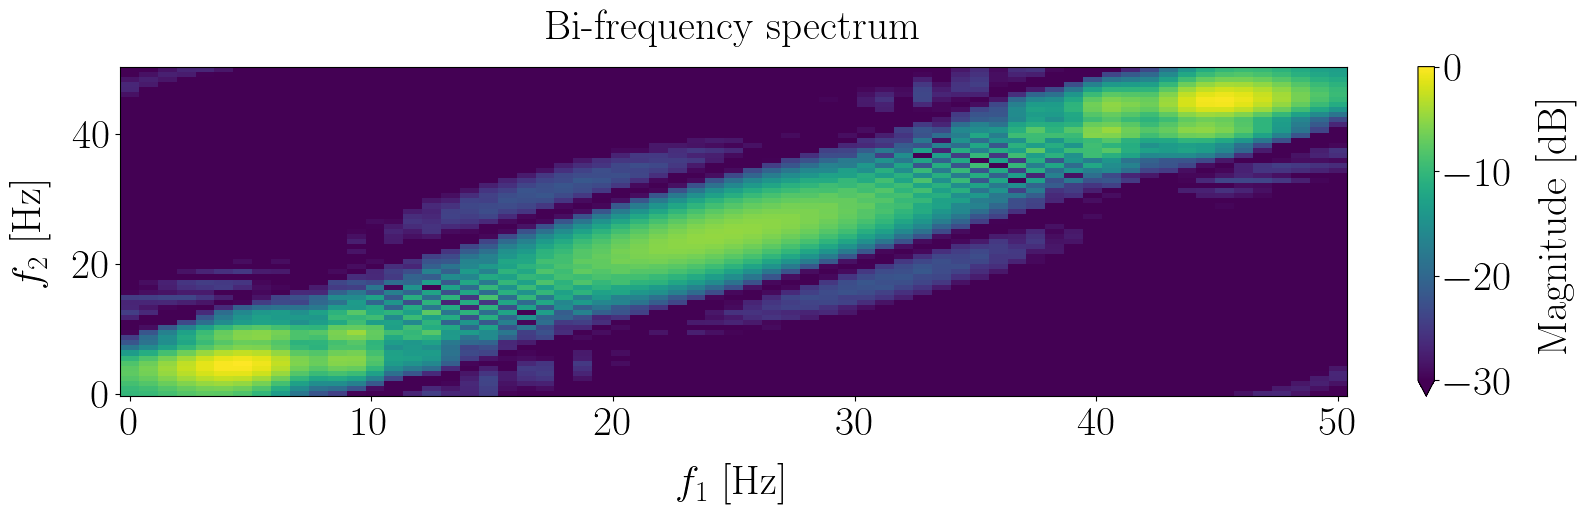

In [79]:
# Bifreq spectrum
ff, S_f1f2 = get_bifrequency_spectrum(
    s=s,
    fs=src_fs,
    fmin=0,
    fmax=50,
    nperseg=2**7,
    noverlap=2**6,
    plot=True,
    root_img=img_folder_path,
)

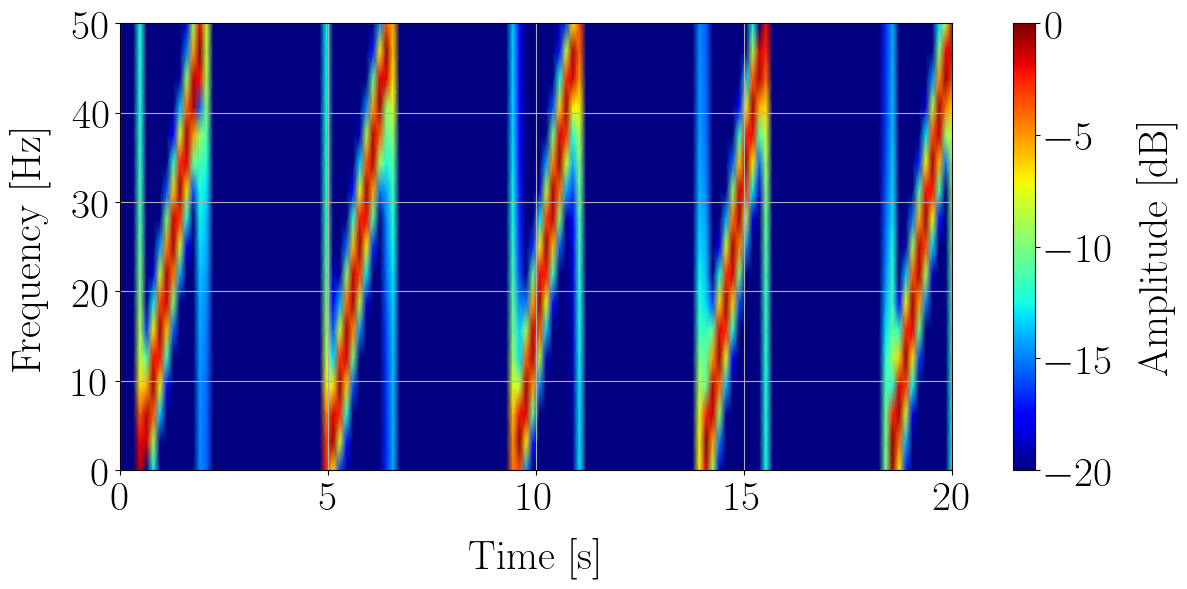

In [80]:
# Derive and plot STFT
window="hann"
nperseg=2**5
noverlap=nperseg //2
ff, tt, Sxx = sp.stft(
    s, fs=src_fs, window=window, nperseg=nperseg, noverlap=noverlap
)

Sxx /= np.max(np.abs(Sxx))
Sxx[Sxx == 0] = 1e-20

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-20, vmax=0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()


In [81]:
# hla_delta_r_rcv = 100  # Receiver range step in meters
hla_nrcv = 5  # Number of receivers in the HLA
hla_sig_grid, _ = build_hla_features(
    tf_xr=ds_tf,
    src=src,
    delta_r_rcv=hla_delta_r_rcv,
    rcv_range=rcv_range,
    rcv_depth=rcv_depth,
    n_rcv=hla_nrcv,
    rmin=None,
    rmax=None,
)

# Get output fs
z_ts = hla_sig_grid.diff("t").t.values[0]
z_fs = 1 / z_ts

Text(0, 0.5, 'Amplitude')

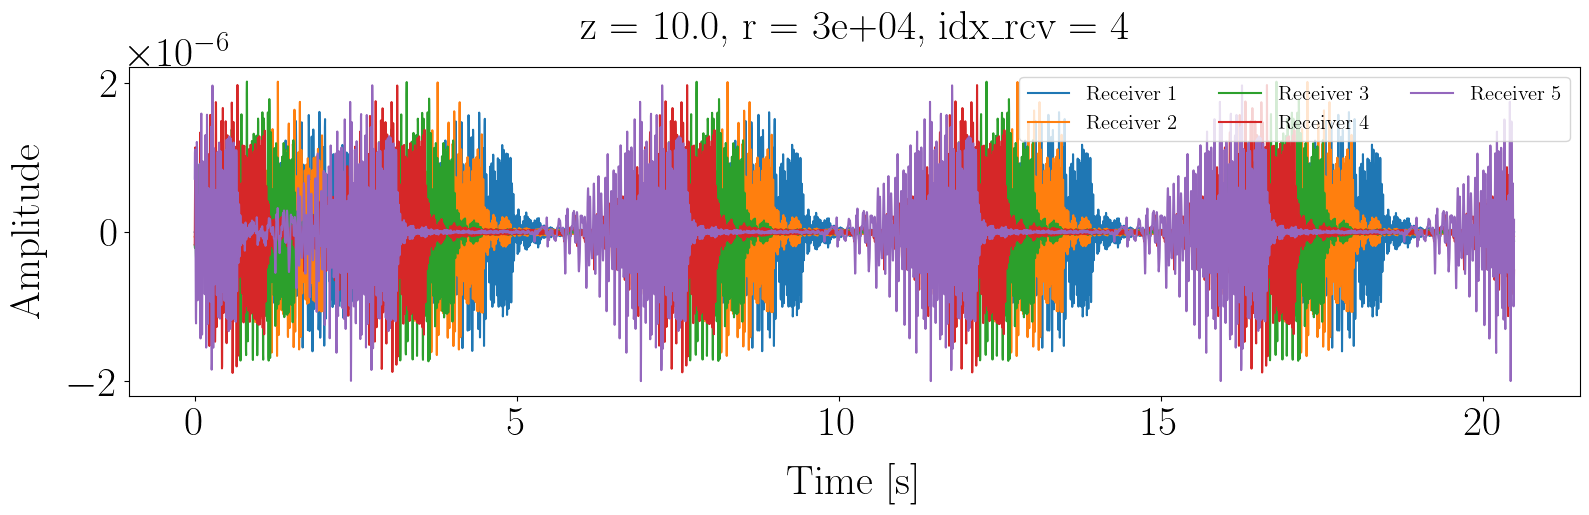

In [82]:
# Visualize signals at each receiver
r_plot = 30 * 1e3
z_plot = 10

lfig = LargeFigure()
plt.figure()
for i in range(hla_nrcv):
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=i).plot(label=f"Receiver {i+1}")
# plt.xlim([9.5, 11.5])
plt.legend(ncols=3, fontsize=15)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

In [83]:
# Save HLA features
hla_sig_grid.attrs = {
    "fs": z_fs,
    "signal_duration": src_signal_duration,
    "source_type": sig_name,
    "antenna": "HLA",
    "delta_r_rcv": hla_delta_r_rcv,
    "n_rcv": hla_nrcv,
    "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
}
hla_sig_grid.to_netcdf(hla_sig_fpath)

(0.0, 50.0)

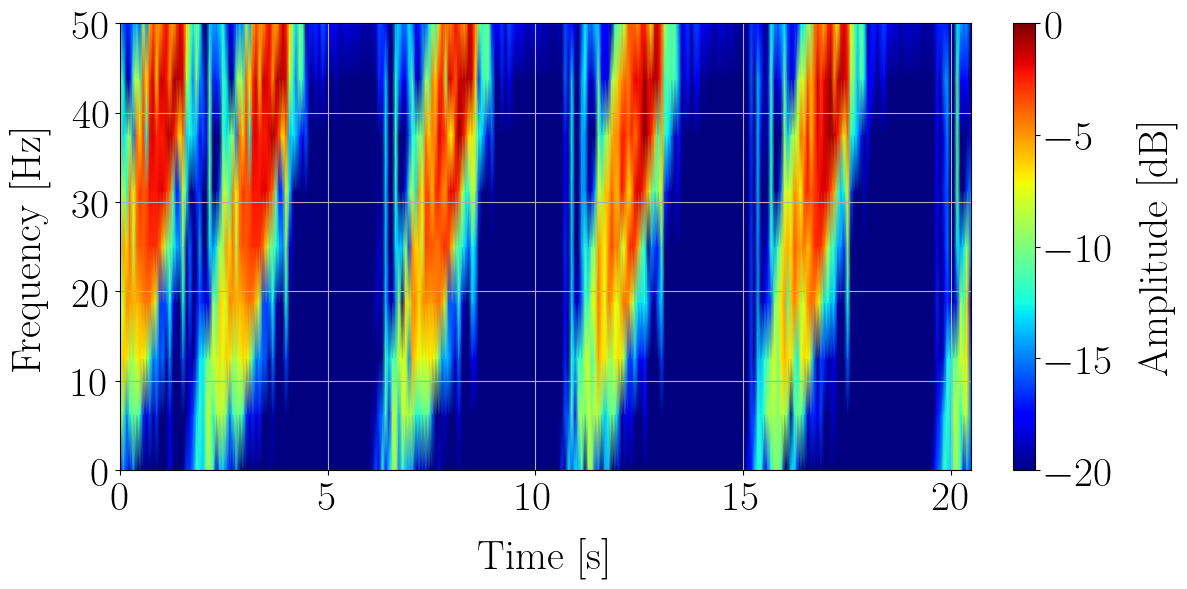

In [84]:
# Derive and plot STFT
window="hann"
nperseg=2**6
noverlap=nperseg // 2
ff, tt, Sxx = sp.stft(
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=2),
    fs=z_fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
)
Sxx /= np.max(np.abs(Sxx))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-20, vmax=-0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()
plt.ylim([0, 50])

## Comparaison des spectres bifréquence


In [85]:
# # Derive bi-spectrum
# fig, axs = plt.subplots(1, len(testcase_infos.keys()))
# for i_tc in range(len(testcase_infos.keys())):
#     hla_sig_ = xr.open_dataset(testcase_infos[i_tc]["hla_sig_fpath"])
#     Xf = np.fft.rfft(hla_sig_.s.sel(r=r_plot, z=z_plot, idx_rcv=2))
#     Xf = np.atleast_2d(Xf)
#     Xff = Xf * np.conj(Xf).T
#     axs[i_tc].imshow(20*np.log10(np.abs(Xff)))
#     # axs[i_tc].set_xlim([0,1000])
#     # axs[i_tc].set_ylim([0, 1000])

# Estimation des vecteurs de RTF

## Load all usefull dataset (to prevent rerunning previous cells)

In [86]:
# First ensure all datasets are closed 
if "hla_sig_grid" in locals():
    hla_sig_grid.close()
    del hla_sig_grid
if "ds_sig"in locals():
    ds_sig.close()
    del ds_sig

testcase_data = {}
for i_tc in testcase_infos.keys():
    ds = xr.open_dataset(testcase_infos[i_tc]["hla_sig_fpath"])
    testcase_data[i_tc] = ds

In [87]:
testcase_data

{0: <xarray.Dataset> Size: 2GB
 Dimensions:  (t: 8192, z: 21, r: 273, idx_rcv: 5)
 Coordinates:
   * t        (t) float64 66kB 0.0 0.0025 0.005 0.0075 ... 20.47 20.48 20.48
   * z        (z) float32 84B 0.0 10.0 20.0 30.0 40.0 ... 170.0 180.0 190.0 200.0
   * r        (r) float64 2kB 1.78e+04 1.79e+04 1.8e+04 ... 4.49e+04 4.5e+04
   * idx_rcv  (idx_rcv) int32 20B 0 1 2 3 4
 Data variables:
     s        (t, z, r, idx_rcv) float64 2GB ...
 Attributes:
     fs:               400.0
     signal_duration:  20.0
     source_type:      pulse
     antenna:          HLA
     delta_r_rcv:      700
     n_rcv:            5
     hla_depth:        999.0,
 1: <xarray.Dataset> Size: 2GB
 Dimensions:  (t: 8192, z: 21, r: 273, idx_rcv: 5)
 Coordinates:
   * t        (t) float64 66kB 0.0 0.0025 0.005 0.0075 ... 20.47 20.48 20.48
   * z        (z) float32 84B 0.0 10.0 20.0 30.0 40.0 ... 170.0 180.0 190.0 200.0
   * r        (r) float64 2kB 1.78e+04 1.79e+04 1.8e+04 ... 4.49e+04 4.5e+04
   * idx_rcv  (idx

In [88]:
# Load HLA RTF
if "hla_rtf_grid" in locals():
    hla_rtf_grid.close()
    del hla_rtf_grid
ds_hla_rtf = xr.open_dataset(hla_rtf_fpath)

In [89]:
ds_hla_rtf

<xarray.Dataset> Size: 81MB
Dimensions:   (f: 1017, z: 6, r: 165, idx_rcv: 5)
Coordinates:
  * f         (f) float64 8kB 0.3906 0.4395 0.4883 0.5371 ... 49.9 49.95 50.0
  * z         (z) float32 24B 5.0 15.0 25.0 35.0 45.0 55.0
  * r         (r) float64 1kB 2.86e+04 2.87e+04 2.88e+04 ... 4.49e+04 4.5e+04
  * idx_rcv   (idx_rcv) int32 20B 0 1 2 3 4
Data variables:
    rtf_real  (f, z, r, idx_rcv) float64 40MB ...
    rtf_imag  (f, z, r, idx_rcv) float64 40MB ...
Attributes:
    fs:               100
    signal_duration:  20.0
    antenna:          HLA
    delta_r_rcv:      700
    n_rcv:            5
    hla_depth:        999.0

## Define analysis params 

In [90]:
delta_snr = 1
snr_min = -5
snr_max = 5
snrs = np.arange(snr_min, snr_max + delta_snr, delta_snr)

idx_rcv_ref = 0

In [91]:
z_fs = testcase_data[0].attrs["fs"]
cov_snapshot_duration = 3   # Duration of the time window to compute the covariance matrix in seconds (should be greater than the impulse response duration)
cov_snapshot_size = int(cov_snapshot_duration * z_fs)  # Number of samples in the time window to compute the covariance matrix
nperseg = 2 ** int(np.log2(cov_snapshot_size) + 1)
noverlap = nperseg // 2
window = "hann"

print(f"Cov snapshot duration: {cov_snapshot_duration} s")
print(f"Associated nperseg: {nperseg} samples")
print(f"Associated noverlap: {noverlap} samples")


Cov snapshot duration: 3 s
Associated nperseg: 2048 samples
Associated noverlap: 1024 samples


In [92]:
# Position where rtf are estimated
r_hat = 30 * 1e3
z_hat = 10

## Initialize RTF estimation tools 

In [93]:
rtf_estimator = RTFEstimator(
    fs=testcase_data[0].attrs["fs"],
    idx_rcv_ref=idx_rcv_ref,
    nperseg=nperseg,
    noverlap=noverlap,
    window=window,
)

In [94]:
# Restrict data to the required position
for i_tc in testcase_data.keys():
    testcase_data[i_tc] = testcase_data[i_tc].sel(r=slice(r_hat, r_hat+0.1), z=slice(z_hat, z_hat+0.1))     # slice +0.1 to keep dimensions 
    # testcase_data[i_tc] = testcase_data[i_tc].sel(r=r_hat, z=z_hat, method="nearest")     # slice +0.1 to keep dimensions

z_fs = testcase_data[0].attrs["fs"]
hla_nrcv = testcase_data[0].attrs["n_rcv"]
# RTF
ds_hla_rtf = ds_hla_rtf.sel(r=slice(r_hat, r_hat+0.1), z=slice(z_hat, z_hat+0.1))  # slice +0.1 to keep dimensions

In [95]:
testcase_data

{0: <xarray.Dataset> Size: 393kB
 Dimensions:  (t: 8192, z: 1, r: 1, idx_rcv: 5)
 Coordinates:
   * t        (t) float64 66kB 0.0 0.0025 0.005 0.0075 ... 20.47 20.48 20.48
   * z        (z) float32 4B 10.0
   * r        (r) float64 8B 3e+04
   * idx_rcv  (idx_rcv) int32 20B 0 1 2 3 4
 Data variables:
     s        (t, z, r, idx_rcv) float64 328kB ...
 Attributes:
     fs:               400.0
     signal_duration:  20.0
     source_type:      pulse
     antenna:          HLA
     delta_r_rcv:      700
     n_rcv:            5
     hla_depth:        999.0,
 1: <xarray.Dataset> Size: 393kB
 Dimensions:  (t: 8192, z: 1, r: 1, idx_rcv: 5)
 Coordinates:
   * t        (t) float64 66kB 0.0 0.0025 0.005 0.0075 ... 20.47 20.48 20.48
   * z        (z) float32 4B 10.0
   * r        (r) float64 8B 3e+04
   * idx_rcv  (idx_rcv) int32 20B 0 1 2 3 4
 Data variables:
     s        (t, z, r, idx_rcv) float64 328kB ...
 Attributes:
     fs:               400.0
     signal_duration:  20.0
     source_type

In [96]:
ds_hla_rtf

<xarray.Dataset> Size: 8kB
Dimensions:   (f: 1017, z: 0, r: 1, idx_rcv: 5)
Coordinates:
  * f         (f) float64 8kB 0.3906 0.4395 0.4883 0.5371 ... 49.9 49.95 50.0
  * z         (z) float32 0B 
  * r         (r) float64 8B 3e+04
  * idx_rcv   (idx_rcv) int32 20B 0 1 2 3 4
Data variables:
    rtf_real  (f, z, r, idx_rcv) float64 0B ...
    rtf_imag  (f, z, r, idx_rcv) float64 0B ...
Attributes:
    fs:               100
    signal_duration:  20.0
    antenna:          HLA
    delta_r_rcv:      700
    n_rcv:            5
    hla_depth:        999.0

In [97]:
rtf_kraken = ds_hla_rtf.rtf_real + 1j * ds_hla_rtf.rtf_imag

## Test with a single SNR to ensure everything is ok 

### Compute and add noise vector 

In [98]:
snr_test = 0
z_xr = testcase_data[3]
noise, noise_mix = generate_noise(z_xr.s, snr=snr_test, idx_rcv_ref=0)

noisy_signal = z_xr.s + noise_mix
noise_only = noise

noisy_signal = noisy_signal.squeeze()
noise_only = noise_only.squeeze()

In [99]:
f, rtf_cs_evd, Rx_evd, Rv_evd = rtf_estimator.covariance_subtraction(
    noisy_signal=noisy_signal,
    noise_only=noise_only,
    use_first_column=False,
    add_id_x=False,
    add_id_v=False,
)

f, rtf_cs_fc, Rx_fc, Rv_fc = rtf_estimator.covariance_subtraction(
    noisy_signal=noisy_signal,
    noise_only=noise_only,
    use_first_column=True,
    add_id_x=False,
    add_id_v=False,
)

f, rtf_cw, Rx, Rv = rtf_estimator.covariance_whitening(
    noisy_signal=noisy_signal,
    noise_only=noise_only,
    add_id_x=False,
    add_id_v=True,
)

In [100]:
# print(Rx_fc[10], Rv_fc[10])
# print(Rx_evd[10], Rv_evd[10])

print(np.allclose(Rx_fc, Rx_evd))
print(np.allclose(Rv_fc, Rv_evd))

True
True


In [101]:
rtf_cs_fc


array([[ 1.        +0.j        ,  0.24578713+0.j        ,
        -0.57722512+0.j        ,  0.38671004+0.j        ,
         0.01210917+0.j        ],
       [ 1.        -0.j        , -1.93018935-0.05795906j,
         0.20632013+0.87398084j,  1.00982686-0.36356612j,
         0.01093695-0.55493923j],
       [ 1.        -0.j        , -0.33525675+0.73187703j,
         0.52740485+0.17799241j,  0.61190747-0.04031261j,
        -0.43063648-0.13305919j],
       ...,
       [ 1.        +0.j        ,  0.04652312-0.73241077j,
        -0.26662242+1.0502441j , -1.11390589+1.99117239j,
        -1.02063679+1.01677098j],
       [ 1.        +0.j        , -0.38602765+0.2755168j ,
        -0.05885871-0.06667038j, -1.50382757+0.86506534j,
         1.06064561+0.21211112j],
       [ 1.        -0.j        , -0.03568969-0.j        ,
         0.64735868-0.j        ,  0.76310268-0.j        ,
        -0.34477397-0.j        ]])

### Compare to true rtf

In [103]:
# lfig = LargeFigure()

# ircv = 4
ymax = 1.5 * np.max(np.abs(rtf_kraken).values)
ymin = 1.5 * np.min(np.abs(rtf_kraken).values)

# plt.figure()
fig, axs = plt.subplots(hla_nrcv-1, 1, sharex=True, figsize=(10, 15))
for ircv in range(1, hla_nrcv):
    ax = axs[ircv-1]
    np.abs(rtf_kraken).sel(idx_rcv=ircv).plot(
        x="f",
        label=r"$\Pi_{" + str(ircv) + r"}^{(Kraken)}$",
        linestyle="-",
        color="k",
        linewidth=1.5,
        ax=ax,
    )

    ax.plot(
        f,
        np.abs(rtf_cs_evd[:, ircv]),
        linestyle="-",
        label=r"$\Pi_{" + str(ircv) + r"}^{(" + "CS-EVD" + r")}$",
        # color="r",
        marker="o",
        linewidth=0.2,
        markersize=3,
    )
    ax.plot(
        f,
        np.abs(rtf_cs_fc[:, ircv]),
        linestyle="-",
        label=r"$\Pi_{" + str(ircv) + r"}^{(" + "CS" + r")}$",
        # color="r",
        marker="o",
        linewidth=0.2,
        markersize=3,
    )
    ax.plot(
        f,
        np.abs(rtf_cw[:, ircv]),
        linestyle="-",
        label=r"$\Pi_{" + str(ircv) + r"}^{(" + "CW" + r")}$",
        # color="r",
        marker="o",
        linewidth=0.2,
        markersize=3,
    )
    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylim([ymin, ymax])
    ax.set_yscale("log")

plt.legend(fontsize=16)
plt.yscale("log")
plt.xlabel(r"$f$" + " [Hz]")
plt.ylabel(r"$|\Pi(f)|$")
plt.xlim([0, 50])
# plt.ylim([1e-1, 1e1])

ValueError: zero-size array to reduction operation maximum which has no identity

On peut ainsi vérifier que les 3 estimateurs convergent vers la solution de référence. On peut également tester l'influence de la taille des fenêtres sur l'estimation : 

* Plus la taille des fenêtres augmentent plus l'estimation est résolue en fréquence (résolution = distance entre deux points) et les structures fines du vecteur de RTF peuvent être correctement caractérisées. 
* En contrepartie, lorsque la taille des snapshots augmente, le nombre de segments pour l'estimation de la matrice de covariance diminue et l'écart à la solution de le référence peut augmenter. 

-> Il y a donc un compromis à trouver 


## Monte carlo simulation for the whole range of SNRs 

In [104]:
def get_rtf_single_estimate(z_xr, snr, estimators, idx_rcv_ref=0, cpu_time=False):
    # Step 1: generate noise and mix it to the signal
    noise, noise_mix = generate_noise(z_xr.s, snr=snr, idx_rcv_ref=idx_rcv_ref)
    noisy_signal = z_xr.s + noise_mix
    noise_only = noise
    noisy_signal = noisy_signal.squeeze()
    noise_only = noise_only.squeeze()

    # Step 2: estimate rtf
    res = {}
    for e in estimators:
        t0 = time.time()
        if e == "cs":
            f, rtf, _, _ = rtf_estimator.covariance_subtraction(
                noisy_signal=noisy_signal,
                noise_only=noise_only,
                use_first_column=True,
                add_id_x=False,
                add_id_v=False,
            )
        elif e == "cs_evd":

            f, rtf, _, _ = rtf_estimator.covariance_subtraction(
                noisy_signal=noisy_signal,
                noise_only=noise_only,
                use_first_column=False,
                add_id_x=False,
                add_id_v=False,
            )

        elif e == "cw":
            f, rtf, _, _ = rtf_estimator.covariance_whitening(
                noisy_signal=noisy_signal,
                noise_only=noise_only,
                add_id_x=False,
                add_id_v=True,
            )
        t1 = time.time()

        res[e] = {"f":f, "rtf":rtf}
        if cpu_time:
            res[e]["cpu_time"] = t1 - t0

    return res

### Run Monte Carlo

In [105]:
run_this_section = False
# run_this_section = True

In [106]:
# n_mc = 50  # Number of monte carlo simulations per snr
# delta_snr = 1
# snr_min = -30
# snr_max = 30

n_mc = 5  # Number of monte carlo simulations per snr
delta_snr = 1
snr_min = -15
snr_max = 15
snrs = np.arange(snr_min, snr_max + delta_snr, delta_snr)

estimators = ["cs", "cs_evd", "cw"]

In [107]:
if run_this_section:

    rtf_estimates = {}

    for i_tc in testcase_data.keys():
        print(f"Testcase {i_tc}: {testcase_data[i_tc].attrs['source_type']}")

        # Get propagated signal
        z_xr = testcase_data[i_tc]
        rtf_estimates[i_tc] = {e:[] for e in estimators}

        for isnr, snr in enumerate(snrs):
            print(f"  SNR = {snr} dB")

            rtf_estimates_isnr = {e: [] for e in estimators}

            for i_mc in range(n_mc):

                if i_mc % 10 == 0 or i_mc == n_mc - 1:
                    print(f"    MC {i_mc+1}/{n_mc}")

                # Process single estimation
                res = get_rtf_single_estimate(z_xr, snr, estimators, idx_rcv_ref=0)
                if i_tc == 0 and i_mc == 0 and isnr == 0:
                    f = res["cs"]["f"]
                    # Here we need to select only the frequencies of interest (i.e in the 0 - 50 Hz band)
                    idx_f_in_band = (rtf_kraken.f.min().values <= f) & (f <= rtf_kraken.f.max().values)
                    f_hat = f[idx_f_in_band]

                # Store result
                for e in estimators:
                    rtf_e = res[e]["rtf"][idx_f_in_band, :]
                    rtf_estimates_isnr[e].append(rtf_e)

            # Convert to array and store for current snr
            for e in estimators:
                rtf_estimates[i_tc][e].append(np.array(rtf_estimates_isnr[e]))

        # Convert to np array
        for e in estimators:
            rtf_estimates[i_tc][e] = np.array(rtf_estimates[i_tc][e])

    rtf_estimates["f"] = f_hat

## Analyse results 

In [108]:
if run_this_section:

    dist_func = D_hermitian_angle_fast
    ax_f = 2
    ax_rcv = 3
    dist_kwargs = {
        "ax_rcv": ax_rcv,
        "unit": "deg",
        "apply_mean": True,
        "ax_f": ax_f,
    }

    # Get reference rtf
    rtf_ref = rtf_kraken.squeeze()
    # Interp common frequencies (in practice we can just use nearest interpolation since the sampling of the estimated rtf vector is proportional to the rtf_ref sampling) This is due
    # to the fact that we use powers of 2 to define stft snapshot length used for cov estimation
    fmin_comp = 10
    f_comp = rtf_estimates["f"]
    # f_comp = f_comp[f_comp >= fmin_comp]
    rtf_ref = rtf_ref.sel(f=f_comp, method="nearest").values

    thetas = {i_tc: {e: [] for e in estimators} for i_tc in testcase_data.keys()}

    expand_rtf_ref = True 
    for i_tc in testcase_infos.keys():
        for e in estimators:
            print(f"Testcase {i_tc}, estimator {e}")
            # Get estimated rtf
            rtf_hat = rtf_estimates[i_tc][e]
            # rtf_hat = rtf_hat[:, :, f_comp >= fmin_comp, :]  # Keep only frequencies in the common band

            if expand_rtf_ref:
                # Expand to the rtf_hat shape for direct derivation of theta for all snr/mc trial
                rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf_hat.shape, missing_dims_axis=[0, 1])
                expand_rtf_ref = False

            # Derive distance
            theta = dist_func(rtf_ref=rtf_ref_expanded, rtf=rtf_hat, **dist_kwargs)       
            print(f"  {e}: {np.mean(theta)} +/- {np.std(theta)} {dist_kwargs['unit']}")

            thetas[i_tc][e] = theta

In [109]:
if run_this_section:
    # Store results in dedicated xarray dataset
    data_vars_dict = {
        f"{testcase_infos[i_tc]['name']}_{e}": (["snr", "mc"], thetas[i_tc][e])
        for i_tc in testcase_infos.keys()
        for e in estimators
    }
    var_names = list(data_vars_dict.keys())

    ds_rtf_perf = xr.Dataset(
        coords=dict(
            snr=snrs,
            mc=np.arange(n_mc),
        ),
        data_vars=data_vars_dict
    )

    # Set attributes to each variable
    for i_tc in testcase_infos.keys():
        for e in estimators:
            name = f"{testcase_infos[i_tc]['name']}_{e}"
            ds_rtf_perf[name].attrs = {
                "description": f"RTF estimation error using {e} estimator for {testcase_infos[i_tc]['name']} source",
                "unit": dist_kwargs["unit"],
                "long_name": f"{testcase_infos[i_tc]['name']} - {e}".upper(),
            }

In [110]:
fpath = os.path.join(data_folder_path, "rtf_estimation_performance.nc")
if run_this_section:
    # Save dataset 
    ds_rtf_perf.to_netcdf(fpath)

else:
    # Load pre-existing dataset
    ds_rtf_perf = xr.open_dataset(fpath)
    var_names = list(ds_rtf_perf.data_vars.keys())


### Plot results 

#### Theta en fonction du SNR pour chaque signal 

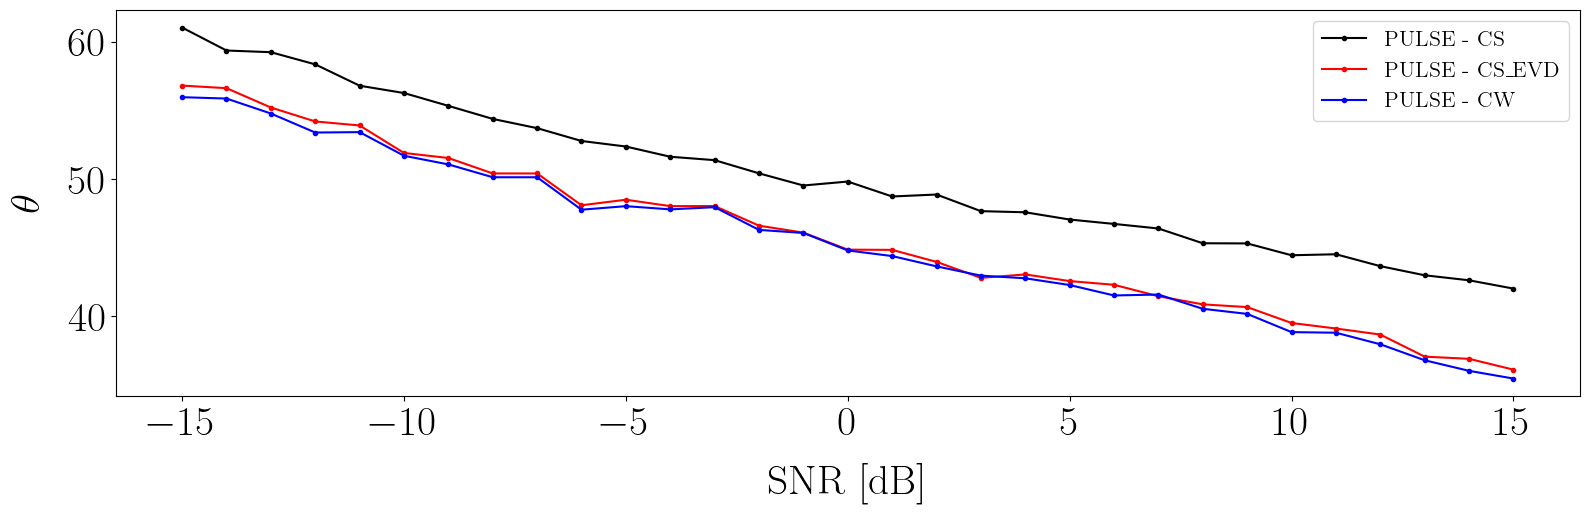

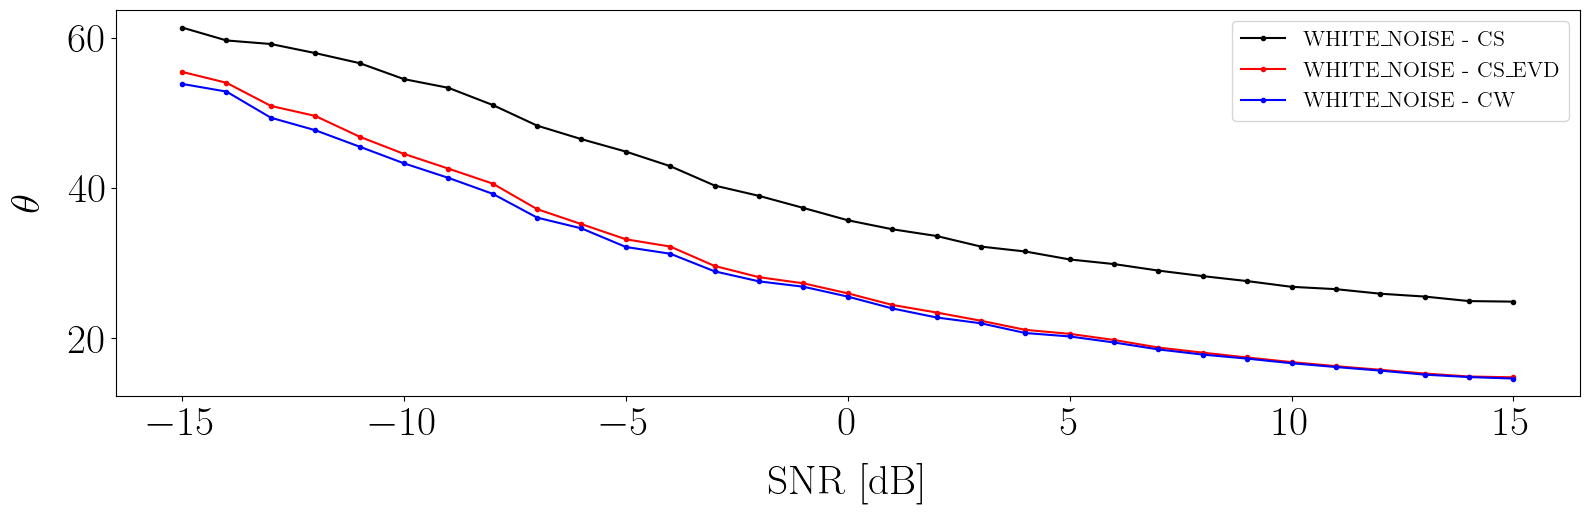

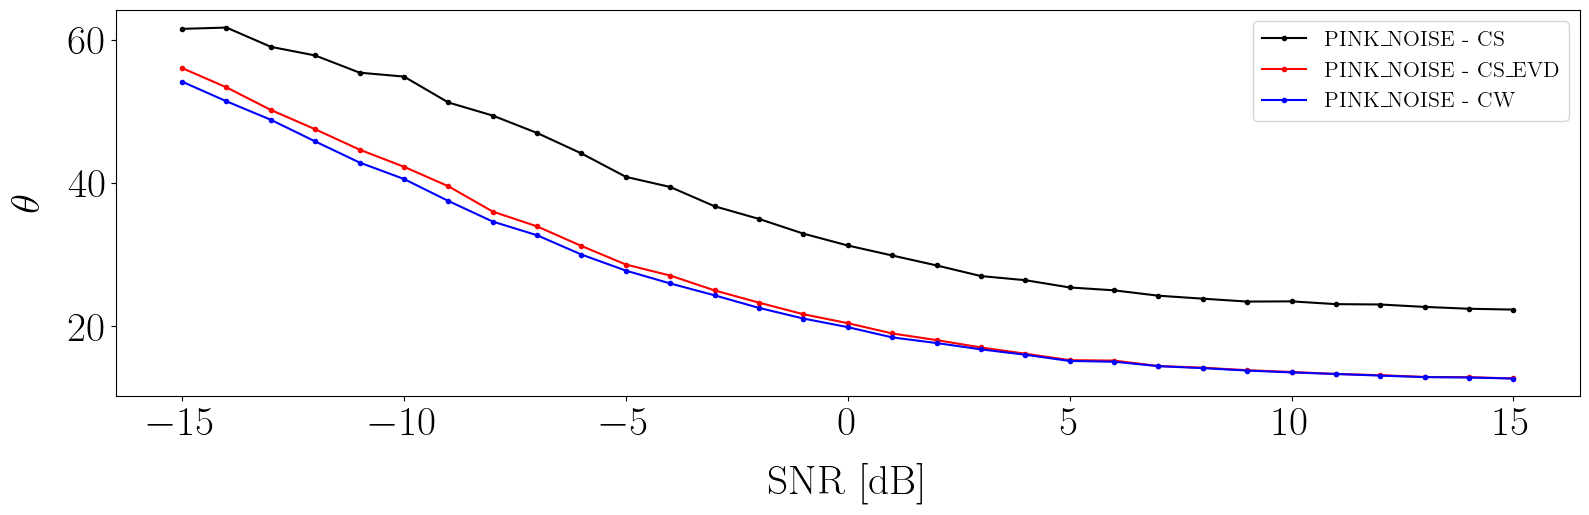

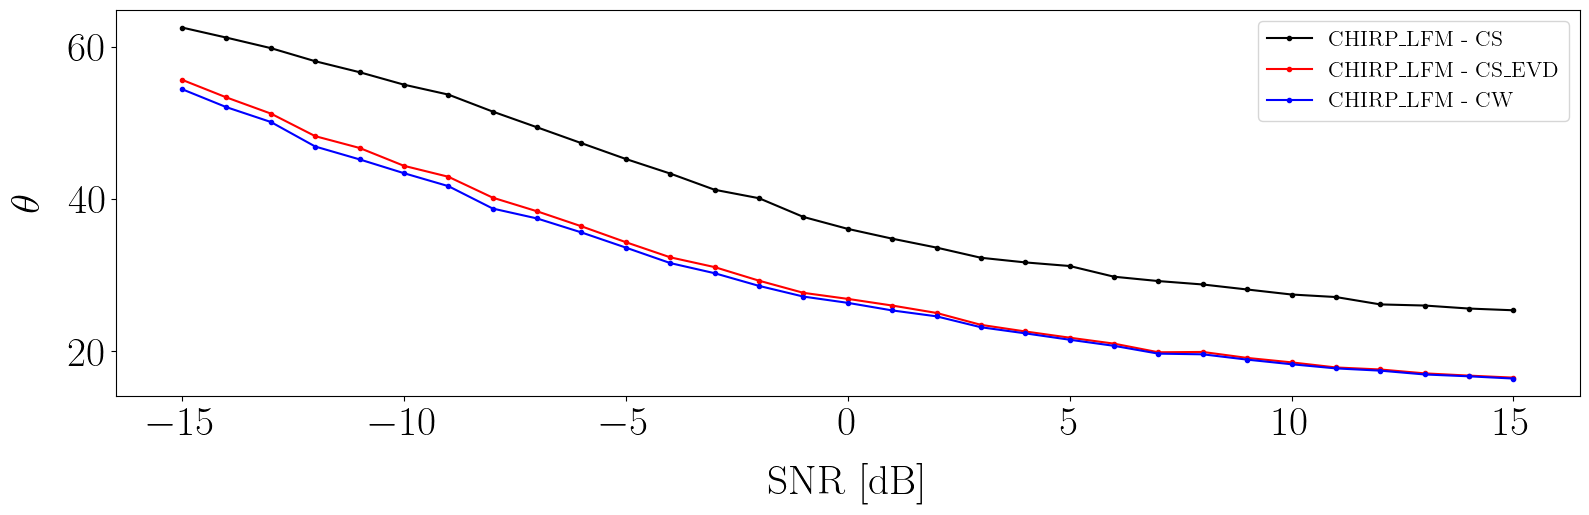

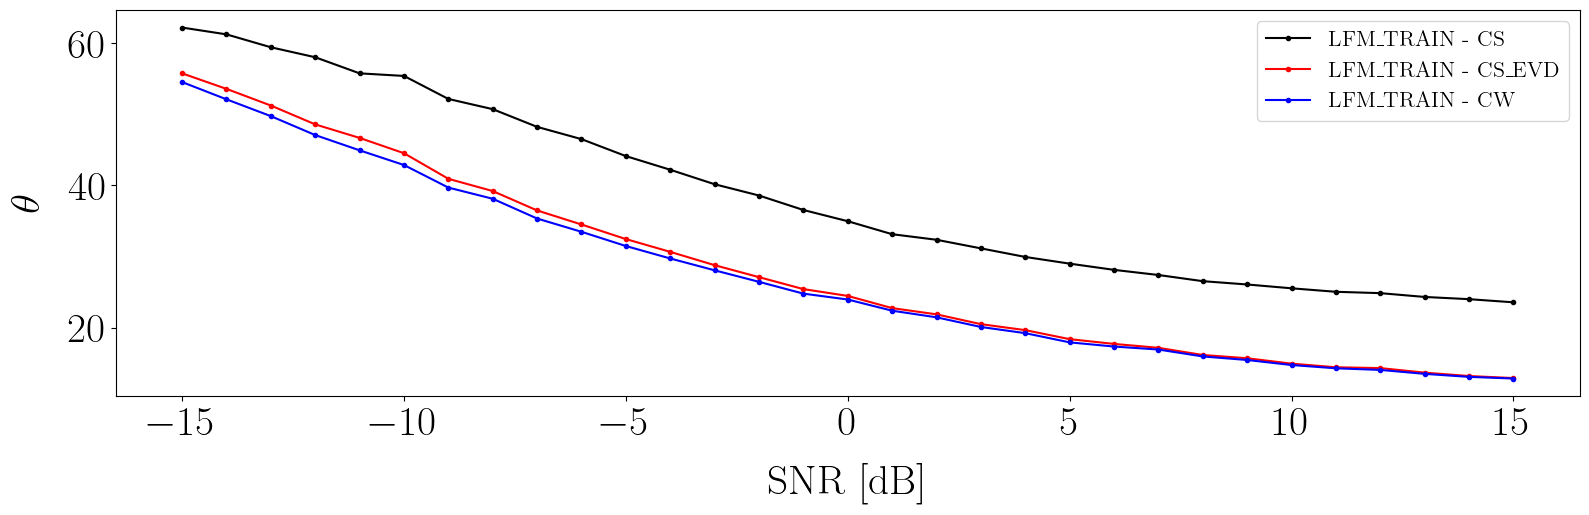

In [111]:
l_fig = LargeFigure()


var_names_idx = [np.array([0, 1, 2]) + 3*i for i in range(len(testcase_infos))]

for i in range(len(testcase_infos)):
    var_names_plot = [
        var_names[k] for k in var_names_idx[i]
    ]  # Select only CS and CS-EVD for clarity
    plt.figure()

    # var_names_plot = var_names  # Plot all
    colors = [
        "k",
        "r",
        "b",
        "g",
        "m",
        "c",
        "y",
        "tab:orange",
        "tab:purple",
        "tab:brown",
        "tab:pink",
        "tab:gray",
    ]
    for name in var_names_plot:
        theta = ds_rtf_perf[name]
        # print(theta)
        theta_mean = theta.mean(dim="mc")
        theta_std = theta.std(dim="mc")

        theta_mean.plot(
            label=theta.long_name,
            marker="o",
            markersize=3,
            linewidth=1.5,
            color=colors.pop(0),
        )
    plt.legend(fontsize=16, ncols=1)
    plt.xlabel("SNR [dB]")
    plt.ylabel(r"$\theta$")

    # Save figure
    # testname = "cs_evd"
    testname = testcase_infos[i]["name"].lower().replace(" ", "_")
    fig_fpath = os.path.join(img_folder_path, f"rtf_estimation_performance_{testname}.pdf")
    plt.savefig(fig_fpath, bbox_inches="tight")

#### Theta en fonction du SNR pour chaque méthode
 

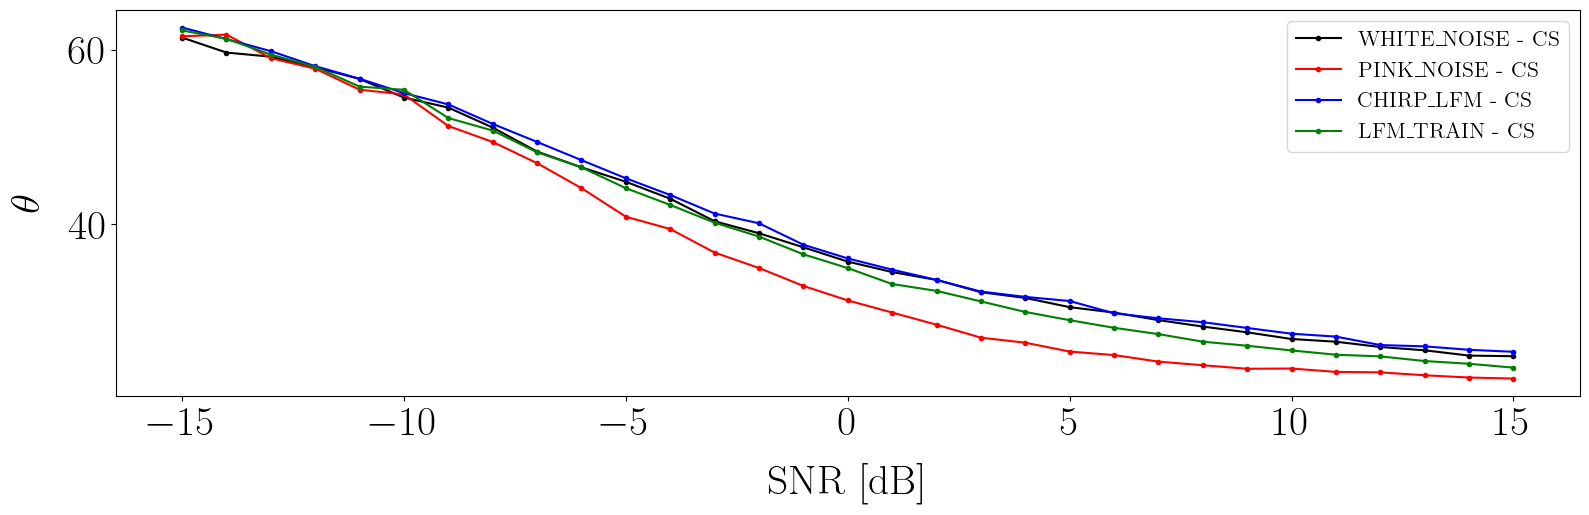

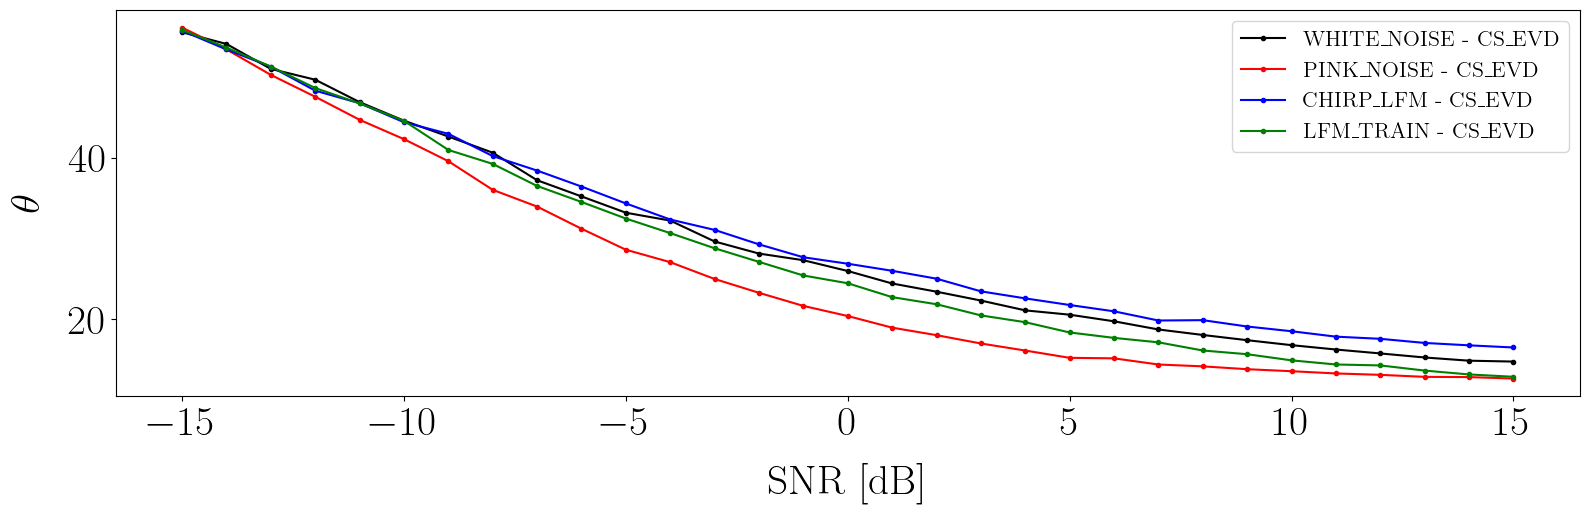

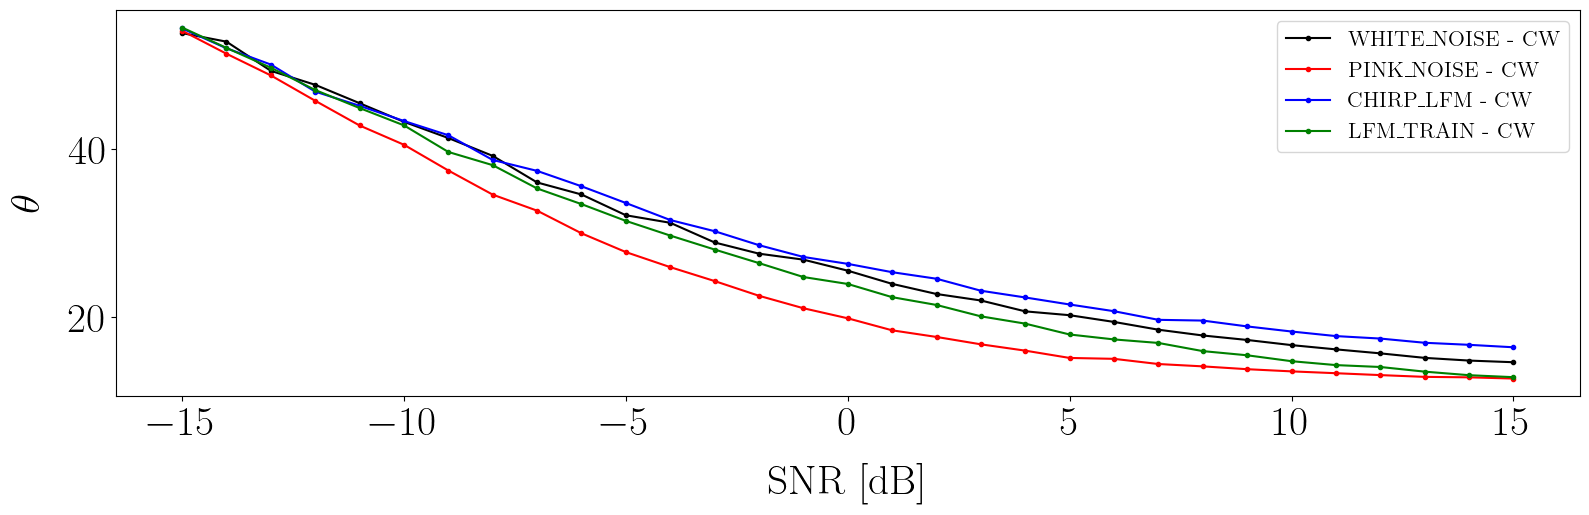

In [112]:
l_fig = LargeFigure()


var_names_idx = [np.array([3, 6, 9, 12]) + i for i in range(len(estimators))]

for i in range(len(estimators)):
    var_names_plot = [
        var_names[k] for k in var_names_idx[i]
    ]  # Select only CS and CS-EVD for clarity
    plt.figure()

    # var_names_plot = var_names  # Plot all
    colors = [
        "k",
        "r",
        "b",
        "g",
        "m",
        "c",
        "y",
        "tab:orange",
        "tab:purple",
        "tab:brown",
        "tab:pink",
        "tab:gray",
    ]
    for name in var_names_plot:
        theta = ds_rtf_perf[name]
        # print(theta)
        theta_mean = theta.mean(dim="mc")
        theta_std = theta.std(dim="mc")

        theta_mean.plot(
            label=theta.long_name,
            marker="o",
            markersize=3,
            linewidth=1.5,
            color=colors.pop(0),
        )
    plt.legend(fontsize=16, ncols=1)
    plt.xlabel("SNR [dB]")
    plt.ylabel(r"$\theta$")

    # Save figure
    # testname = "cs_evd"
    testname = estimators[i].lower().replace(" ", "_")
    fig_fpath = os.path.join(img_folder_path, f"rtf_estimation_performance_{testname}.pdf")
    plt.savefig(fig_fpath, bbox_inches="tight")

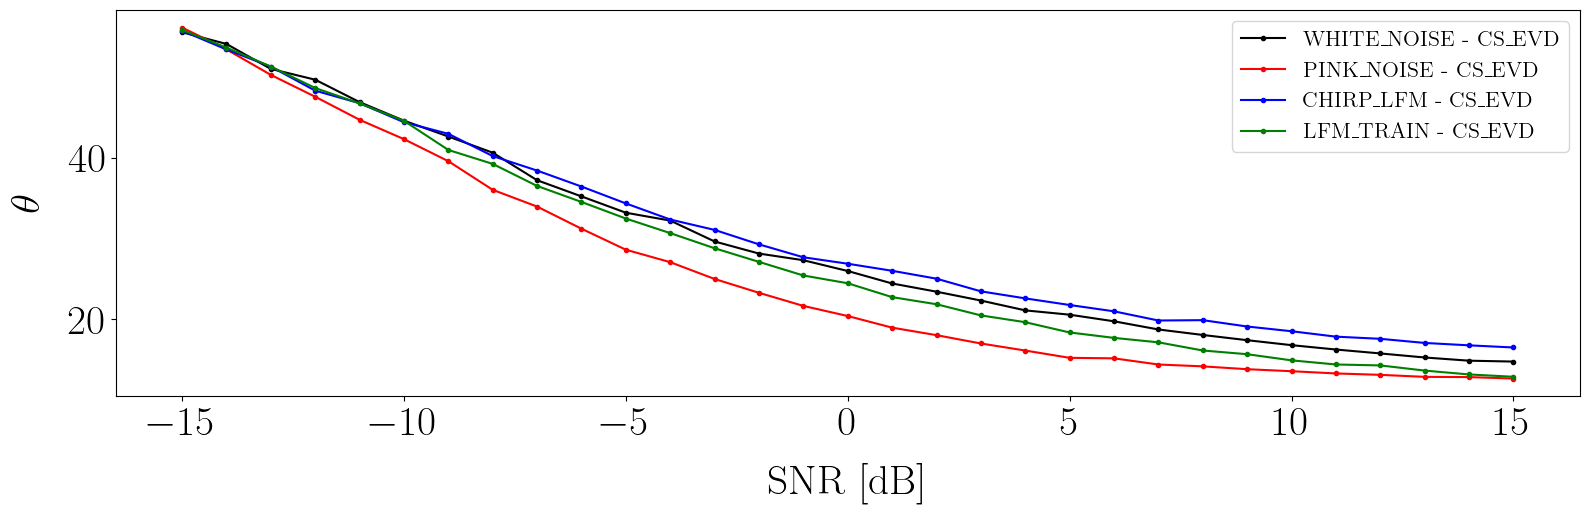

In [113]:
l_fig = LargeFigure()

plt.figure()

var_names_plot = [var_names[i] for i in [4,7,10,13]]  # Select only CS and CS-EVD for clarity
# var_names_plot = var_names  # Plot all
colors = ["k", "r", "b", "g", "m", "c", "y", "tab:orange", "tab:purple", "tab:brown", "tab:pink", "tab:gray"]
for name in var_names_plot:
    theta = ds_rtf_perf[name]
    # print(theta)
    theta_mean = theta.mean(dim="mc")
    theta_std = theta.std(dim="mc")
    # print(f"{name}: {theta_mean.values} +/- {theta_std.values} {theta.unit}")
    # plt.errorbar(
    #     ds_rtf_perf.snr,
    #     theta_mean,
    #     yerr=theta_std,
    #     label=theta.long_name,
    #     marker="o",
    #     markersize=6,
    #     linewidth=1,
    #     capsize=5,
    # )
    theta_mean.plot(
        label=theta.long_name,
        marker="o",
        markersize=3,
        linewidth=1.5,
        color=colors.pop(0)
    )
plt.legend(fontsize=16, ncols=1)
plt.xlabel("SNR [dB]")
plt.ylabel(r"$\theta$")

# Save figure
testname = "cs_evd"
fig_fpath = os.path.join(img_folder_path, f"rtf_estimation_performance_{testname}.pdf")
plt.savefig(fig_fpath, bbox_inches="tight")

In [114]:
for name in var_names_plot:
    theta = ds_rtf_perf[name]
    theta_mean = theta.mean(dim="mc")
    print(f"{name}: max theta = {theta_mean.max().values} {theta.unit}")
    print(f"{name}: min theta = {theta_mean.min().values} {theta.unit}")

white_noise_cs_evd: max theta = 55.476296029188475 deg
white_noise_cs_evd: min theta = 14.78842908752797 deg
pink_noise_cs_evd: max theta = 56.05527367003697 deg
pink_noise_cs_evd: min theta = 12.689991353220575 deg
chirp_lfm_cs_evd: max theta = 55.661341547703785 deg
chirp_lfm_cs_evd: min theta = 16.528858620923476 deg
lfm_train_cs_evd: max theta = 55.76014321145317 deg
lfm_train_cs_evd: min theta = 12.911320729196053 deg


## Analyse de l'influence de la taille des fenêtres STFT 

In [116]:
snr = 0
n_mc = 10
window = "hann"

# Select one test case to use
i_tc = 1
tc_name = testcase_infos[i_tc]["name"]

z_xr = testcase_data[i_tc]
print(f"Testcase {i_tc}: {testcase_infos[i_tc]['name']}")

z_fs = testcase_data[i_tc].attrs["fs"]
cov_snapshot_duration_min = 2  # Duration of the time window to compute the covariance matrix in seconds (should be greater than the impulse response duration)
cov_snapshot_size = int(
    cov_snapshot_duration_min * z_fs
)  # Number of samples in the time window to compute the covariance matrix

nperseg_min = 2 ** int(np.log2(cov_snapshot_size) + 1)
nperseg_max = 2 ** int(np.log2(testcase_data[0].sizes["t"])) # Max is the ~ full signal length 
noverlap = nperseg // 2

nperseg_values = [2**i for i in range(int(np.log2(nperseg_min))-1, int(np.log2(nperseg_max))+1)]

results_nperseg = {}
for nperseg in nperseg_values:
    noverlap = nperseg // 2
    print(f"nperseg: {nperseg}, noverlap: {noverlap}")

    rtf_estimator = RTFEstimator(
        fs=z_fs,
        idx_rcv_ref=idx_rcv_ref,
        nperseg=nperseg,
        noverlap=noverlap,
        window=window,
    )

    for i_mc in range(n_mc):

        if i_mc % 10 == 0 or i_mc == n_mc - 1:
            print(f"  MC {i_mc+1}/{n_mc}")

        # Process single estimation
        res = get_rtf_single_estimate(z_xr, snr, estimators, idx_rcv_ref=0)
        if i_mc == 0:
            f = res["cs"]["f"]
            # Here we need to select only the frequencies of interest (i.e in the 0 - 50 Hz band)
            # fmin = rtf_kraken.f.min().values
            fmin = 10
            idx_f_in_band = (fmin <= f) & (f <= rtf_kraken.f.max().values)
            f_hat = f[idx_f_in_band]

        # Store result
        for e in estimators:
            if nperseg not in results_nperseg.keys():
                results_nperseg[nperseg] = {e: [] for e in estimators}
            rtf_e = res[e]["rtf"][idx_f_in_band, :]
            results_nperseg[nperseg][e].append(rtf_e)
            
    # Convert to array and store for current nperseg
    for e in estimators:
        results_nperseg[nperseg][e] = np.array(results_nperseg[nperseg][e])     # shape (n_mc, n_f, n_rcv)

    # Add frequency vector
    results_nperseg[nperseg]["f"] = f_hat

Testcase 1: white_noise
nperseg: 512, noverlap: 256
  MC 1/10
  MC 10/10
nperseg: 1024, noverlap: 512
  MC 1/10
  MC 10/10
nperseg: 2048, noverlap: 1024
  MC 1/10
  MC 10/10
nperseg: 4096, noverlap: 2048
  MC 1/10
  MC 10/10
nperseg: 8192, noverlap: 4096
  MC 1/10
  MC 10/10


In [ ]:
# Derive theta distance for each nperseg/estimator
dist_func = D_hermitian_angle_fast
ax_f = 2
ax_rcv = 3
dist_kwargs = {
    "ax_rcv": ax_rcv,
    "unit": "deg",
    "apply_mean": True,
    "ax_f": ax_f,
}

# Get reference rtf
rtf_ref = rtf_kraken.squeeze()

thetas = {e: [] for e in estimators}

for nperseg in nperseg_values:
    set_rtf_ref = True
    for e in estimators: 
        # print(f"nperseg {nperseg}, estimator {e}")
        # Get estimated rtf
        rtf_hat = results_nperseg[nperseg][e]
        # Add one dummy dimension to get a 4D array (needed for the dist function)
        rtf_hat = rtf_hat[np.newaxis, ...]

        if set_rtf_ref:
            # Interp to common frequencies
            rtf_ref_nperseg = rtf_ref.sel(
                f=results_nperseg[nperseg]["f"], method="nearest"
            ).values
            # Expand to the rtf_hat shape for direct derivation of theta for all snr/mc trial
            rtf_ref_expanded = cast_matrix_to_target_shape(
                rtf_ref_nperseg, rtf_hat.shape
            )
            # Reset to false for next estimators
            set_rtf_ref = False

        # Derive distance
        theta = dist_func(rtf_ref=rtf_ref_expanded, rtf=rtf_hat, **dist_kwargs)
        thetas[e].append(theta)

# Convert to np arrays
for e in estimators:
    thetas[e] = np.array(thetas[e])   # shape (n_nperseg, n_mc)

In [ ]:
# Store results in dedicated xarray dataset
data_vars_dict = {
   e: (["nperseg", "mc"], thetas[e]) for e in estimators
}
var_names = list(data_vars_dict.keys())
ds_rtf_perf_nperseg = xr.Dataset(
    coords=dict(
        nperseg=nperseg_values,
        mc=np.arange(n_mc),
    ),
    data_vars=data_vars_dict
)
# Set attributes to each variable
for e in estimators:
    ds_rtf_perf_nperseg[e].attrs = {
        "description": f"RTF estimation error using {e} estimator for {testcase_infos[i_tc]['name']} source as a function of nperseg",
        "unit": dist_kwargs["unit"],
        "long_name": f"{testcase_infos[i_tc]['name']} - {e}".upper(),
    }

In [ ]:
ds_rtf_perf_nperseg

In [ ]:
# Save dataset
fpath = os.path.join(
    data_folder_path, f"rtf_estimation_performance_nperseg_snr{snr}dB_{tc_name}.nc"
)
ds_rtf_perf_nperseg.to_netcdf(fpath)

In [ ]:
# Plot results
l_fig = LargeFigure()

plt.figure()
# var_names_plot = [var_names[i] for i in [0,3]]  # Select only CS and CS-EVD for clarity
var_names_plot = var_names  # Plot all

colors = ["k", "r", "b"]
for name in var_names_plot:
    theta = ds_rtf_perf_nperseg[name]
    # print(theta)
    theta_mean = theta.mean(dim="mc")
    theta_std = theta.std(dim="mc")
    # print(f"{name}: {theta_mean.values} +/- {theta_std.values} {theta.unit}")
    plt.errorbar(
        ds_rtf_perf_nperseg.nperseg,
        theta_mean,
        yerr=theta_std,
        label=theta.long_name,
        marker="o",
        markersize=6,
        linewidth=1,
        capsize=5,
        color=colors.pop(0)
    )
    # theta_mean.plot(
    #     label=theta.long_name,
    #     marker="o",
    #     markersize=6,
    #     linewidth=1,
    # )

plt.legend(fontsize=16, ncols=3)
plt.xlabel(r"$n_{\textrm{STFT}}$")
plt.xscale("log", base=2)
# plt.xticks(nperseg_values, nperseg_values)
plt.ylabel(r"$\theta$")

# Add arrow to indicate min nperseg
plt.annotate(
    "",
    xy=(nperseg_min, 25),
    xytext=(nperseg_min, 20),
    arrowprops=dict(color="red", shrink=0.05, width=1, headwidth=8),
)


# plt.ylim([15, 25])
# Save figure
fpath_fig = os.path.join(img_folder_path, f"rtf_estimation_performance_nperseg_snr{snr}dB_{tc_name}.pdf")
plt.savefig(fpath_fig, dpi=300)

In [ ]:
# Visual comparison of the RTF estimations for different nperseg values
lfig = LargeFigure()

nperseg_plot = [1024, 2048, 4096, 8192]
est = "cs_evd"
est_name = est.upper()

ircv = 1
ymax = 1.5 * np.max(np.abs(rtf_kraken).values)
ymin = 1.5 * np.min(np.abs(rtf_kraken).values)

plt.figure()


colors = ["r", "g", "b", "m"]

for nperseg in nperseg_plot:
    plt.plot(
        results_nperseg[nperseg]["f"],
        np.abs(results_nperseg[nperseg][est][0,:, ircv]),
        linestyle="-",
        label=r"$\Pi_{" + str(ircv) + r"}^{(" + est_name + r")}$" + fr" - $n_{{\mathrm{{STFT}}}}$={nperseg}",
        color=colors.pop(0),
        marker="o",
        linewidth=1.5,
        markersize=3,
    )

np.abs(rtf_kraken).sel(idx_rcv=ircv).plot(
    x="f",
    label=r"$\Pi_{" + str(ircv) + r"}^{(Kraken)}$",
    linestyle="-",
    color="k",
    linewidth=1.5,
)

plt.title("")
plt.legend(fontsize=16, ncols=4)
plt.yscale("log")
plt.xlabel(r"$f$" + " [Hz]")
plt.ylabel(r"$|\Pi(f)|$")
plt.xlim([10, 50])
plt.ylim([5 * 1e-2, 5 * 1e1])

# Save figure
fpath_fig = os.path.join(img_folder_path, f"rtf_estimation_comparison_pi_nperseg_snr{snr}dB_{tc_name}.pdf")
plt.savefig(fpath_fig, dpi=300)

In [ ]:
# Visual comparison of the RTF estimations for different nperseg values
lfig = LargeFigure(size=(16, 5.25*2), legend_fontsize=16)

nperseg_plot_ = [1024, 2048, 4096, 8192]
est = "cs_evd"
est_name = est.upper()

ircv = 1
ymax = 1.5 * np.max(np.abs(rtf_kraken).values)
ymin = 1.5 * np.min(np.abs(rtf_kraken).values)

# plt.figure()
fig, axs = plt.subplots(2, 1, sharex=True)


colors = ["r", "g", "b", "m"]

for i_ax, ax in enumerate(axs):
    plt.sca(ax)
    nperseg_plot = nperseg_plot_[(i_ax*2):(i_ax*2+2)]
    for nperseg in nperseg_plot:
        plt.plot(
            results_nperseg[nperseg]["f"],
            np.abs(results_nperseg[nperseg][est][0, :, ircv]),
            linestyle="-",
            label=rf"$n_{{\mathrm{{STFT}}}}$={nperseg}",
            color=colors.pop(0),
            marker="o",
            linewidth=1.5,
            markersize=3,
        )

    np.abs(rtf_kraken).sel(idx_rcv=ircv).plot(
        x="f",
        label=r"$\Pi_{" + str(ircv) + r"}^{(Kraken)}$",
        linestyle="-",
        color="k",
        linewidth=1.5,
    )

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.legend(ncol=3, loc="upper right")
    ax.set_ylim([ymin, ymax])
    ax.set_xlim([10, 50])
    ax.set_yscale("log")
    ax.set_title("")


fig.suptitle("")
# plt.title("")
# plt.legend(fontsize=16, ncols=4)
plt.yscale("log")
fig.supxlabel(r"$f$" + " [Hz]")
fig.supylabel(r"$|\Pi(f)|$")
plt.xlim([10, 50])
plt.ylim([5 * 1e-2, 5 * 1e1])

# Save figure
fpath_fig = os.path.join(
    img_folder_path, f"rtf_estimation_comparison_pi_nperseg_snr{snr}dB_{tc_name}.pdf"
)
plt.savefig(fpath_fig, dpi=300)

### Etude de la taille de fenetre optimale en fonction du SNR 


In [ ]:
run_this_section = False
# run_this_section = True

In [ ]:
if run_this_section:
    snrs = np.arange(-5, 5 + 1, 1)
    n_mc = 2

    # snrs = np.arange(-15, 15+1, 1)
    # n_mc = 10
    window = "hann"

    dist_func = D_hermitian_angle_fast
    ax_f = 2
    ax_rcv = 3
    dist_kwargs = {
        "ax_rcv": ax_rcv,
        "unit": "deg",
        "apply_mean": True,
        "ax_f": ax_f,
    }

    # Select one test case to use
    i_tc = 1
    tc_name = testcase_infos[i_tc]["name"]

    z_xr = testcase_data[i_tc]
    print(f"Testcase {i_tc}: {testcase_infos[i_tc]['name']}")

    z_fs = testcase_data[i_tc].attrs["fs"]
    cov_snapshot_duration_min = 2  # Duration of the time window to compute the covariance matrix in seconds (should be greater than the impulse response duration)
    cov_snapshot_size = int(
        cov_snapshot_duration_min * z_fs
    )  # Number of samples in the time window to compute the covariance matrix

    nperseg_min = 2 ** int(np.log2(cov_snapshot_size) + 1)
    nperseg_max = 2 ** int(
        np.log2(testcase_data[0].sizes["t"])
    )  # Max is the ~ full signal length
    noverlap = nperseg // 2

    nperseg_values = [
        2**i for i in range(int(np.log2(nperseg_min)) - 2, int(np.log2(nperseg_max)))
    ]
    print(f"nperseg_min: {nperseg_min}, nperseg_max: {nperseg_max}")
    print(f"nperseg values: {nperseg_values}")


    for snr in snrs:
        print(f"SNR = {snr} dB")

        results_nperseg = {}
        for nperseg in nperseg_values:
            noverlap = nperseg // 2
            print(f"nperseg: {nperseg}, noverlap: {noverlap}")

            rtf_estimator = RTFEstimator(
                fs=z_fs,
                idx_rcv_ref=idx_rcv_ref,
                nperseg=nperseg,
                noverlap=noverlap,
                window=window,
            )

            for i_mc in range(n_mc):

                if i_mc % 10 == 0 or i_mc == n_mc - 1:
                    print(f"  MC {i_mc+1}/{n_mc}")

                # Process single estimation
                res = get_rtf_single_estimate(z_xr, snr, estimators, idx_rcv_ref=0)
                if i_mc == 0:
                    f = res["cs"]["f"]
                    # Here we need to select only the frequencies of interest (i.e in the 0 - 50 Hz band)
                    # fmin = rtf_kraken.f.min().values
                    fmin = 10
                    idx_f_in_band = (fmin <= f) & (f <= rtf_kraken.f.max().values)
                    f_hat = f[idx_f_in_band]

                # Store result
                for e in estimators:
                    if nperseg not in results_nperseg.keys():
                        results_nperseg[nperseg] = {e: [] for e in estimators}
                    rtf_e = res[e]["rtf"][idx_f_in_band, :]
                    results_nperseg[nperseg][e].append(rtf_e)

            # Convert to array and store for current nperseg
            for e in estimators:
                results_nperseg[nperseg][e] = np.array(
                    results_nperseg[nperseg][e]
                )  # shape (n_mc, n_f, n_rcv)

            # Add frequency vector
            results_nperseg[nperseg]["f"] = f_hat

        # Derive theta distance for each nperseg/estimator
        # Get reference rtf
        rtf_ref = rtf_kraken.squeeze()

        thetas = {e: [] for e in estimators}

        for nperseg in nperseg_values:
            set_rtf_ref = True
            for e in estimators:
                # print(f"nperseg {nperseg}, estimator {e}")
                # Get estimated rtf
                rtf_hat = results_nperseg[nperseg][e]
                # Add one dummy dimension to get a 4D array (needed for the dist function)
                rtf_hat = rtf_hat[np.newaxis, ...]

                if set_rtf_ref:
                    # Interp to common frequencies
                    rtf_ref_nperseg = rtf_ref.sel(
                        f=results_nperseg[nperseg]["f"], method="nearest"
                    ).values
                    # Expand to the rtf_hat shape for direct derivation of theta for all snr/mc trial
                    rtf_ref_expanded = cast_matrix_to_target_shape(
                        rtf_ref_nperseg, rtf_hat.shape
                    )
                    # Reset to false for next estimators
                    set_rtf_ref = False

                # Derive distance
                theta = dist_func(rtf_ref=rtf_ref_expanded, rtf=rtf_hat, **dist_kwargs)
                thetas[e].append(theta)

        # Convert to np arrays
        for e in estimators:
            thetas[e] = np.array(thetas[e])  # shape (n_nperseg, n_mc)
        # Store results in dedicated xarray dataset
        data_vars_dict = {e: (["nperseg", "mc"], thetas[e]) for e in estimators}
        var_names = list(data_vars_dict.keys())
        ds_rtf_perf_nperseg = xr.Dataset(
            coords=dict(
                nperseg=nperseg_values,
                mc=np.arange(n_mc),
            ),
            data_vars=data_vars_dict,
        )
        # Set attributes to each variable
        for e in estimators:
            ds_rtf_perf_nperseg[e].attrs = {
                "description": f"RTF estimation error using {e} estimator for {testcase_infos[i_tc]['name']} source as a function of nperseg",
                "unit": dist_kwargs["unit"],
                "long_name": f"{testcase_infos[i_tc]['name']} - {e}".upper(),
            }

        # Save dataset
        fpath = os.path.join(
            data_folder_path, f"rtf_estimation_performance_nperseg_snr{snr}dB_{tc_name}.nc"
        )
        ds_rtf_perf_nperseg.to_netcdf(fpath)

In [ ]:

# Load datasets and find optimum nperseg for each snr
nperseg_opti = {e: {"opti" :[], "name": ""} for e in estimators}

for snr in snrs:
    fpath = os.path.join(
        data_folder_path, f"rtf_estimation_performance_nperseg_snr{snr}dB_{tc_name}.nc"
    )
    ds_rtf_perf_nperseg = xr.open_dataset(fpath)

    for e in estimators:
        theta = ds_rtf_perf_nperseg[e]
        theta_mean = theta.mean(dim="mc")
        idx_min = theta_mean.argmin().values
        nperseg_opti[e]["opti"].append(ds_rtf_perf_nperseg.nperseg.values[idx_min])
        nperseg_opti[e]["name"] = theta.long_name

In [ ]:
nperseg_opti

In [ ]:
# Plot results
l_fig = LargeFigure()

# estimators_plot = ["cs_evd"]
estimators_plot = estimators

colors = ["k", "r", "b"]
plt.figure()
for e in estimators_plot:
    plt.plot(
        snrs,
        nperseg_opti[e]["opti"],
        label=e.upper(),
        marker="o",
        markersize=6,
        linewidth=1,
        color=colors.pop(0)
    )

plt.legend(fontsize=16, ncols=1)
plt.xlabel("SNR [dB]")
plt.ylabel(r"$n_{\textrm{STFT}}^{\textrm{opt}}$")
plt.yscale("log", base=2)

# Save figure
fpath_fig = os.path.join(img_folder_path, f"rtf_estimation_performance_nperseg_opti_{tc_name}.pdf")
plt.savefig(fpath_fig, dpi=300)

### Evaluation de l'angle hermitien à chaque bin fréquentiel vs SNR dans la bande 

In [ ]:
# Derive rtf at optimum nperseg for a given snr

snr = 0
n_mc = 100

print(f"SNR = {snr} dB")

window = "hann"
nperseg = 2**11  # From previous plot for snr=0dB and CS-EVD estimator
noverlap = nperseg // 2

print(f"nperseg: {nperseg}, noverlap: {noverlap}")

rtf_estimator = RTFEstimator(
    fs=z_fs,
    idx_rcv_ref=idx_rcv_ref,
    nperseg=nperseg,
    noverlap=noverlap,
    window=window,
)


dist_func = D_hermitian_angle_fast
ax_f = 2
ax_rcv = 3
dist_kwargs = {
    "ax_rcv": ax_rcv,
    "unit": "deg",
    "apply_mean": False,        # NOTE : this is the main change compared to previous blocks
    "ax_f": ax_f,
}

# Select one test case to use
i_tc = 1
tc_name = testcase_infos[i_tc]["name"]

z_xr = testcase_data[i_tc]
z_fs = testcase_data[i_tc].attrs["fs"]
print(f"Testcase {i_tc}: {testcase_infos[i_tc]['name']}")

results = {e: [] for e in estimators}
for i_mc in range(n_mc):

    if i_mc % 10 == 0 or i_mc == n_mc - 1:
        print(f"  MC {i_mc+1}/{n_mc}")

    # Process single estimation
    res = get_rtf_single_estimate(z_xr, snr, estimators, idx_rcv_ref=0)
    if i_mc == 0:
        f = res["cs"]["f"]
        # Here we need to select only the frequencies of interest (i.e in the 0 - 50 Hz band)
        # fmin = rtf_kraken.f.min().values
        fmin = 10
        idx_f_in_band = (fmin <= f) & (f <= rtf_kraken.f.max().values)
        f_hat = f[idx_f_in_band]

    # Store result
    for e in estimators:
        rtf_e = res[e]["rtf"][idx_f_in_band, :]
        results[e].append(rtf_e)

# Convert to array and store for current nperseg
for e in estimators:
    results[e] = np.array(results[e])  # 

# Add frequency vector
results["f"] = f_hat

# Derive theta distance for each nperseg/estimator
# Get reference rtf
rtf_ref = rtf_kraken.squeeze()

thetas = {e: [] for e in estimators}

set_rtf_ref = True
for e in estimators:
    # print(f"nperseg {nperseg}, estimator {e}")
    # Get estimated rtf
    rtf_hat = results[e]
    # Add one dummy dimension to get a 4D array (needed for the dist function)
    rtf_hat = rtf_hat[np.newaxis, ...]

    if set_rtf_ref:
        # Interp to common frequencies
        rtf_ref_ = rtf_ref.sel(
            f=results["f"], method="nearest"
        ).values
        # Expand to the rtf_hat shape for direct derivation of theta for all snr/mc trial
        rtf_ref_expanded = cast_matrix_to_target_shape(
            rtf_ref_, rtf_hat.shape
        )
        # Reset to false for next estimators
        set_rtf_ref = False

    # Derive distance
    theta = dist_func(rtf_ref=rtf_ref_expanded, rtf=rtf_hat, **dist_kwargs)     # shape (nf, n_mc)
    thetas[e] = theta


# Store results in dedicated xarray dataset
data_vars_dict = {e: (["f", "mc"], thetas[e]) for e in estimators}
var_names = list(data_vars_dict.keys())
ds_rtf_perf_freq = xr.Dataset(
    coords=dict(
        f=results["f"],
        mc=np.arange(n_mc),
    ),
    data_vars=data_vars_dict,
)
# Set attributes to each variable
for e in estimators:
    ds_rtf_perf_freq[e].attrs = {
        "description": f"RTF estimation error using {e} estimator for {testcase_infos[i_tc]['name']} source as a function of frequency",
        "unit": dist_kwargs["unit"],
        "long_name": f"{testcase_infos[i_tc]['name']} - {e}".upper(),
    }

# Save dataset
fpath = os.path.join(
    data_folder_path, f"rtf_estimation_performance_freq_snr{snr}dB_{tc_name}.nc"
)
ds_rtf_perf_freq.to_netcdf(fpath)

In [ ]:
ds_rtf_perf_freq

In [ ]:
# Derive received SNR
noise, noise_mix = generate_noise(z_xr.s, snr=snr, idx_rcv_ref=idx_rcv_ref)
noisy_signal = z_xr.s + noise_mix

# Extract signal at reference microphone
noisy_signal = noisy_signal.values.squeeze()
x = noisy_signal[:, idx_rcv_ref]
# Extract corresponding noise
noise_mix = noise_mix.squeeze()
v = noise_mix[:, idx_rcv_ref]

# Derive SNR at each frequency
# PSD of noisy signal
f_snr, Sxx = sp.welch(
    x,
    fs=z_fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
    return_onesided=True,
)

# PSD of noise only
_, Svv = sp.welch(
    v,
    fs=z_fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
    return_onesided=True,
)
gamma_f  = Sxx / Svv
snr_dB = 10 * np.log10(gamma_f)

df = f_snr[1] - f_snr[0]
pxx_tot = np.sum(Sxx) * df
pvv_tot = np.sum(Svv) * df
print(f"Overall SNR = {10*np.log10(pxx_tot/pvv_tot)} dB")

In [ ]:
# Plot PSDs and SNR
lfig = LargeFigure(size=(16, 5.25*2), legend_fontsize=16)
fig, axs = plt.subplots(2, 1, sharex=True)
colors = ["r", "g", "b", "m"]
for i_ax, ax in enumerate(axs):
    plt.sca(ax)
    if i_ax == 0:
        plt.plot(f_snr, 10*np.log10(Sxx), label="Noisy signal", color="b")
        plt.plot(f_snr, 10 * np.log10(Svv), label="Noise only", color="r")
        plt.ylabel("PSD [dB]")
        # plt.ylim([1e-7, 1e2])
        plt.legend()
        plt.title("")
    else:
        plt.plot(f_snr, snr_dB, label="Received SNR", color="k")
        plt.axhline(snr, linestyle="--", color="r", label="Input SNR")
        plt.xlabel("Frequency [Hz]")
        plt.ylabel("SNR [dB]")
        plt.ylim([snr - 15, snr + 15])
        plt.legend()
        plt.title("")

plt.xlim([10, 50])

In [ ]:
# Plot mean theta as a function of frequency
l_fig = LargeFigure(legend_fontsize=18, language=language)

estimators_plot = ["cs", "cs_evd", "cw"]
fig, ax1 = plt.subplots()

# Twin axis for received snr
ax2 = ax1.twinx()
ax1.plot(f_snr, -snr_dB, color="k", linestyle="-", linewidth=2, marker="o")
# ax1.set_ylabel(
#     r"$- 10 \textrm{log}_{10} \left ( \frac{S_{xx} (f)} {S_{vv}(f)} \right ) \, \textrm{[dB]}$"
# )
ax1.set_ylabel(
    r"$- \Gamma_{\textrm{dB}}(f)  \, \textrm{[dB]}$"
)

colors = ["r", "b", "g"]
for e in estimators_plot:
    theta = ds_rtf_perf_freq[e]
    theta_mean = theta.mean(dim="mc")
    theta_std = theta.std(dim="mc")

    # theta_mean.plot(
    #     label=theta.long_name,
    #     marker="o",
    #     markersize=3,
    #     linewidth=1.5,
    #     color=colors.pop(0),
    #     ax=ax2
    # )
    theta_mean.plot(
        label=theta.long_name,
        linestyle="-",
        marker="o",
        markersize=3,
        linewidth=1.5,
        color=colors.pop(0),
        ax=ax2,
    )


plt.ylabel(r"$\theta$ [°]")

# Plot SNR
# plt.twinx()
# plt.reverse_yaxis()
# plt.plot(f, -snr_dB, color="tab:orange", label="SNR")
plt.xlim([10, 50])

plt.legend(ncol=3)
lfig.f_label.set_axis_label("x")

In [ ]:
import pandas as pd
window_size = 10

# Same plot but apply rolling mean to smooth the curves
lfig = LargeFigure(legend_fontsize=18, language=language)
fig, ax1 = plt.subplots()
# Twin axis for received snr
ax2 = ax1.twinx()

snr_dB_roll = pd.Series(snr_dB).rolling(window=window_size, center=True).mean()
ax1.plot(f_snr, -snr_dB_roll, color="k", linestyle="-", linewidth=2)
# ax1.set_ylabel(
#     r"$- 10 \textrm{log}_{10} \left ( \frac{S_{xx} (f)} {S_{vv}(f)} \right ) \, \textrm{[dB]}$"
# )
ax1.set_ylabel(
    r"$- \Gamma_{\textrm{dB}}(f)  \, \textrm{[dB]}$"
)
colors = ["r", "b", "g"]
for e in estimators_plot:
    theta = ds_rtf_perf_freq[e]
    theta_mean = theta.mean(dim="mc").rolling(f=window_size, center=True).mean()
    # theta_std = theta.std(dim="mc").rolling(f=window_size, center=True).mean()

    # theta_mean.plot(
    #     label=theta.long_name,
    #     marker="o",
    #     markersize=3,
    #     linewidth=1.5,
    #     color=colors.pop(0),
    #     ax=ax2
    # )
    theta_mean.plot(
        label=theta.long_name,
        linestyle="-",
        marker="o",
        markersize=3,
        linewidth=1.5,
        color=colors.pop(0),
        ax=ax2,
    )

plt.ylabel(r"$\theta$ [°]")
plt.xlim([10, 50])

plt.legend(ncol=3)
ax1.set_xlabel("f [Hz]")

### Etude tu temps de calcul associé à chacune des méthodes 

In [ ]:
run_cpu_section = False

In [ ]:
z_fs = testcase_data[0].attrs["fs"]
cov_snapshot_duration = 2   # Duration of the time window to compute the covariance matrix in seconds (should be greater than the impulse response duration)
cov_snapshot_size = int(cov_snapshot_duration * z_fs)  # Number of samples in the time window to compute the covariance matrix
nperseg = 2 ** int(np.log2(cov_snapshot_size) + 1)
noverlap = nperseg // 2
window = "hann"

print(f"Cov snapshot duration: {cov_snapshot_duration} s")
print(f"Associated nperseg: {nperseg} samples")
print(f"Associated noverlap: {noverlap} samples")


In [ ]:
rtf_estimator = RTFEstimator(
    fs=testcase_data[0].attrs["fs"],
    idx_rcv_ref=idx_rcv_ref,
    nperseg=nperseg,
    noverlap=noverlap,
    window=window,
)

In [ ]:
n_mc = 1000  # Number of monte carlo simulations per snr
snr = 0
estimators = ["cs", "cs_evd", "cw"]

In [ ]:
if run_cpu_section:
    cpu_times = {}

    for i_tc in testcase_data.keys():
        print(f"Testcase {i_tc}: {testcase_data[i_tc].attrs['source_type']}")

        # Get propagated signal
        z_xr = testcase_data[i_tc]

        cpu_times[i_tc] = {e: [] for e in estimators}

        for i_mc in range(n_mc):

            if i_mc % 10 == 0 or i_mc == n_mc - 1:
                print(f"    MC {i_mc+1}/{n_mc}")

            # Process single estimation
            res = get_rtf_single_estimate(z_xr, snr, estimators, idx_rcv_ref=0, cpu_time=True)

            # Store result
            for e in estimators:
                cpu_times[i_tc][e].append(res[e]["cpu_time"])

        # Convert to array and store for current snr
        for e in estimators:
            cpu_times[i_tc][e] = np.array(cpu_times[i_tc][e])


In [ ]:
fpath = os.path.join(data_folder_path, "rtf_estimation_cpu_time.nc")


if run_cpu_section:
    # Store results in dedicated xarray dataset
    data_vars_dict = {
        f"{testcase_infos[i_tc]['name']}_{e}": (["mc"], cpu_times[i_tc][e])
        for i_tc in testcase_data.keys()
        for e in estimators
    }

    var_names = list(data_vars_dict.keys())
    ds_cpu_time = xr.Dataset(
        coords=dict(
            mc=np.arange(n_mc),
        ),
        data_vars=data_vars_dict
    )

    # Set attributes to each variable
    for i_tc in testcase_infos.keys():
        for e in estimators:
            name = f"{testcase_infos[i_tc]['name']}_{e}"
            ds_cpu_time[name].attrs = {
                "description": f"RTF estimation cpu time using {e} estimator for {testcase_infos[i_tc]['name']} source",
                "unit": "s",
                "long_name": f"{testcase_infos[i_tc]['name']} - {e}".upper(),
            }
            
    # Save dataset
    ds_cpu_time.to_netcdf(fpath)
else:
    ds_cpu_time = xr.open_dataset(fpath)


In [ ]:

# Plot results
l_fig = LargeFigure()

plt.figure()
var_names_plot = list(ds_cpu_time.data_vars.keys())
# Sort var names to have same methods together
# var_names_plot = sorted(var_names_plot, key=lambda x: x.split("_")[-1])
# Sort to have same source together
var_names_plot = sorted(var_names_plot, key=lambda x: x.split("_")[0])

colors = ["k", "r", "b", "g"]

# Define pos for each variable
x_pos = np.arange(len(var_names_plot))
# Define associated x ticks labels
x_labels = []
for i, name in enumerate(var_names_plot):
    cpu_time = ds_cpu_time[name]
    # print(cpu_time)
    cpu_time_mean = cpu_time.mean(dim="mc")
    cpu_time_std = cpu_time.std(dim="mc")
    # print(f"{name}: {cpu_time_mean.values} +/- {cpu_time_std.values} {cpu_time.unit}")
    x_labels.append(cpu_time.long_name.split(" - ")[0].lower())
    e = name.split("_")[-1]
    if e == "cs":
        c = "k"
    elif e == "evd":
        c = "r"
    elif e == "cw":
        c = "b"

    plt.errorbar(
        x_pos[i],
        cpu_time_mean,
        yerr=cpu_time_std,
        marker="o",
        markersize=6,
        linewidth=1,
        capsize=5,
        color=c,
    )

idx = [1, 4, 7, 10, 13]
x_pos = x_pos[idx]  # Keep only one entry per source 
x_labels = [x_labels[i] for i in idx]  # Keep only one entry per source
plt.xticks(x_pos, x_labels, rotation=0, ha="center")

# Add legend for the colors
black_patch = mpatches.Patch(color='k', label='CS')
red_patch = mpatches.Patch(color='r', label='CS-EVD')
blue_patch = mpatches.Patch(color='b', label='CW')
plt.legend(handles=[black_patch, red_patch, blue_patch], fontsize=16, ncols=1, loc="upper right", bbox_to_anchor=(1,1))

# plt.legend(fontsize=16, ncols=1, )
# plt.xlabel("Monte Carlo trial")
plt.ylabel("CPU time [s]")
# plt.yscale("log")
# plt.ylim([1e-3, 1e1])

# Save figure
fpath_fig = os.path.join(img_folder_path, f"rtf_estimation_cpu_time.pdf")
plt.savefig(fpath_fig, dpi=300)
